In [ ]:
import pandas as pd
from utils import *
    df = pd.read_csv("../data/cleaned.csv")

In [5]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),delivery_city
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,Sunny,High,2,Snack,motorcycle,0,No,Urban,24,Indore
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,33,Bangalore
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26,Bangalore
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,...,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,21,Coimbatore
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,...,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,30,Chennai


## EDA

### 1. Label columns into below 3 categories

In [6]:
num_col = ['Delivery_person_Age','Delivery_person_Ratings','multiple_deliveries', 'Time_taken(min)']

cat_col = ['Weatherconditions', 'Road_traffic_density','Vehicle_condition', 'Type_of_order', 'Type_of_vehicle','multiple_deliveries', 'Festival', 'City', 'delivery_city']

mix_col = ['ID', 'Delivery_person_ID', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked']

### 2. Univariate Analysis

#### numerical cols

UNIVARIATE ANALYSIS FOR NUMERICAL COLUMNS

ANALYZING: Delivery_person_Age

1. DESCRIPTIVE STATISTICS:
count    38064.000000
mean        29.608948
std          5.761658
min         20.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         39.000000
Name: Delivery_person_Age, dtype: float64

2. SKEWNESS: -0.029
   → Approximately symmetric

3. OUTLIER DETECTION (IQR method):
   - Lower bound: 10.00
   - Upper bound: 50.00
   - Number of outliers: 0 (0.00%)


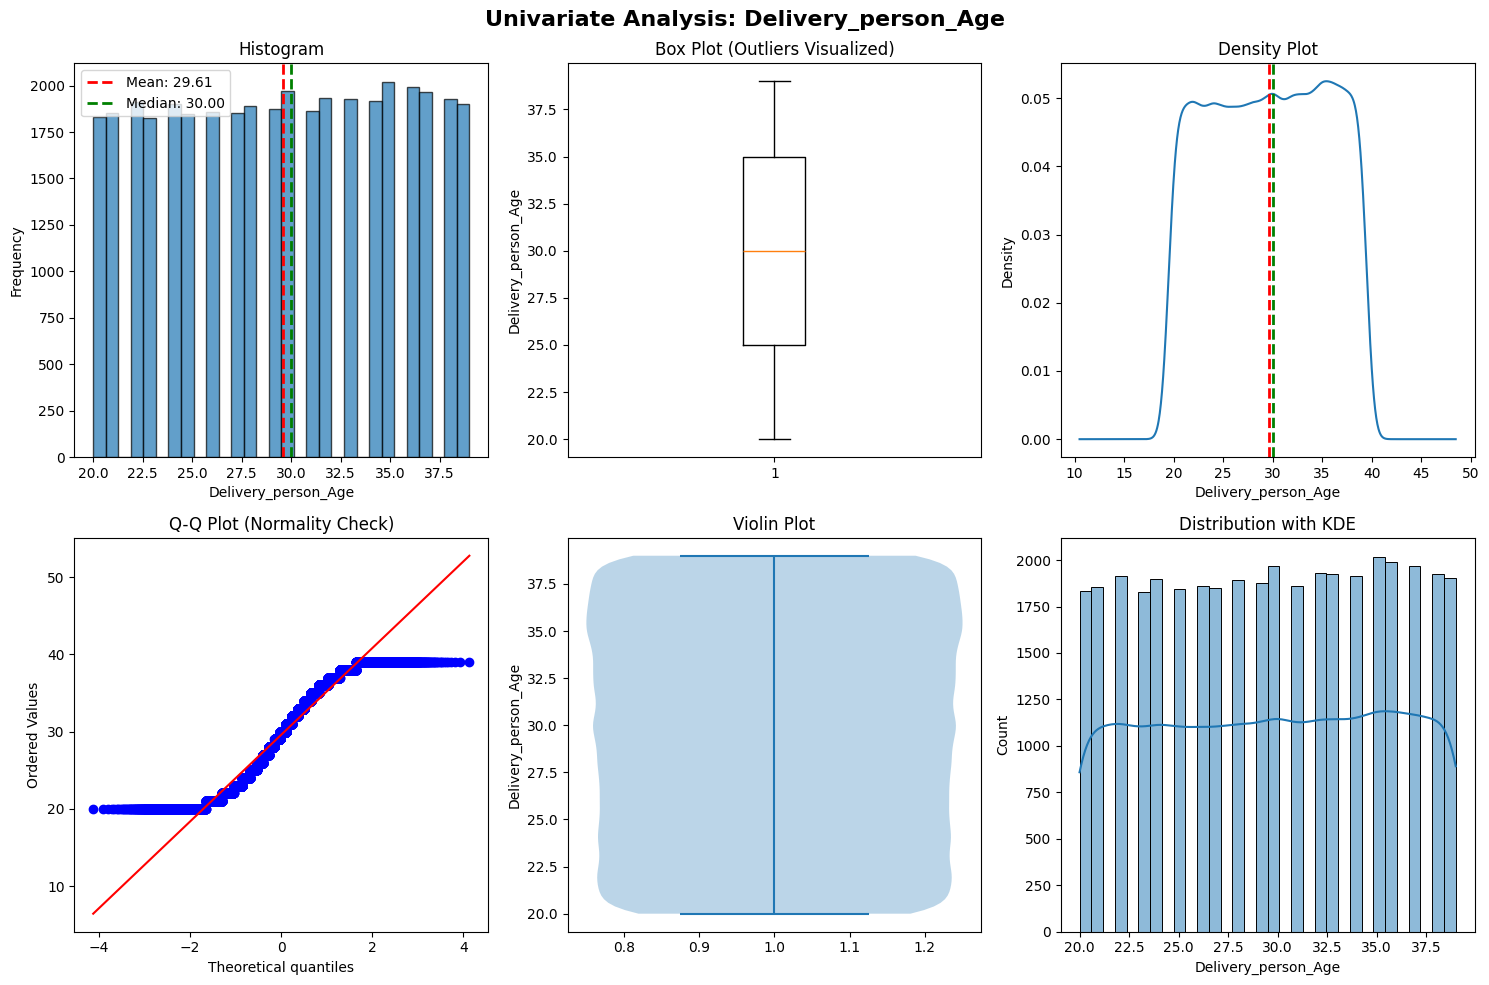


4. RECOMMENDATIONS:
   → Skewness is within acceptable range. No transformation needed.

--------------------------------------------------

ANALYZING: Delivery_person_Ratings

1. DESCRIPTIVE STATISTICS:
count    38064.00000
mean         4.63187
std          0.31695
min          2.50000
25%          4.50000
50%          4.70000
75%          4.90000
max          5.00000
Name: Delivery_person_Ratings, dtype: float64

2. SKEWNESS: -1.772
   → Highly left-skewed (negative skew)

3. OUTLIER DETECTION (IQR method):
   - Lower bound: 3.90
   - Upper bound: 5.50
   - Number of outliers: 1030 (2.71%)
   - Outlier values: [2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5, 2.5]


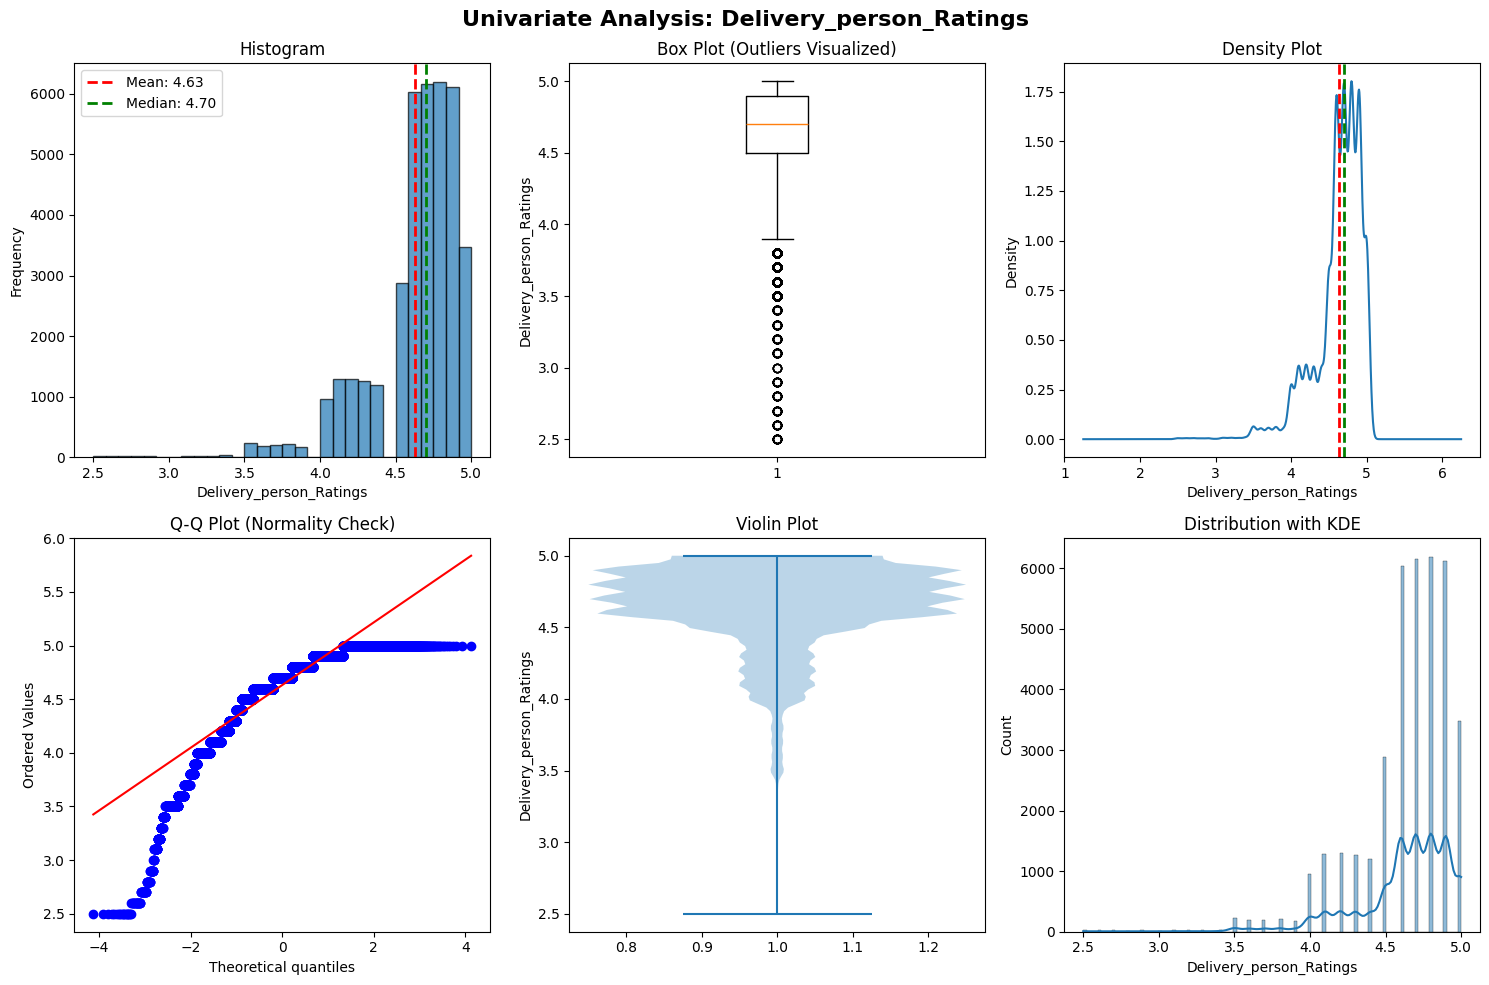


4. RECOMMENDATIONS:
   → High skewness detected (-1.77). Consider:
      - Log transformation: np.log1p(df[col])
      - Square root transformation: np.sqrt(df[col])
      - Box-Cox transformation: scipy.stats.boxcox(df[col])
   → 2.7% outliers present. Consider:
      - Keeping if they represent real extreme values
      - Removing if they are data entry errors
      - Using robust metrics (median, IQR)

--------------------------------------------------

ANALYZING: multiple_deliveries

1. DESCRIPTIVE STATISTICS:
count    38064.000000
mean         0.748818
std          0.572731
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: multiple_deliveries, dtype: float64

2. SKEWNESS: 0.320
   → Approximately symmetric

3. OUTLIER DETECTION (IQR method):
   - Lower bound: -1.50
   - Upper bound: 2.50
   - Number of outliers: 306 (0.80%)
   - Outlier values: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]


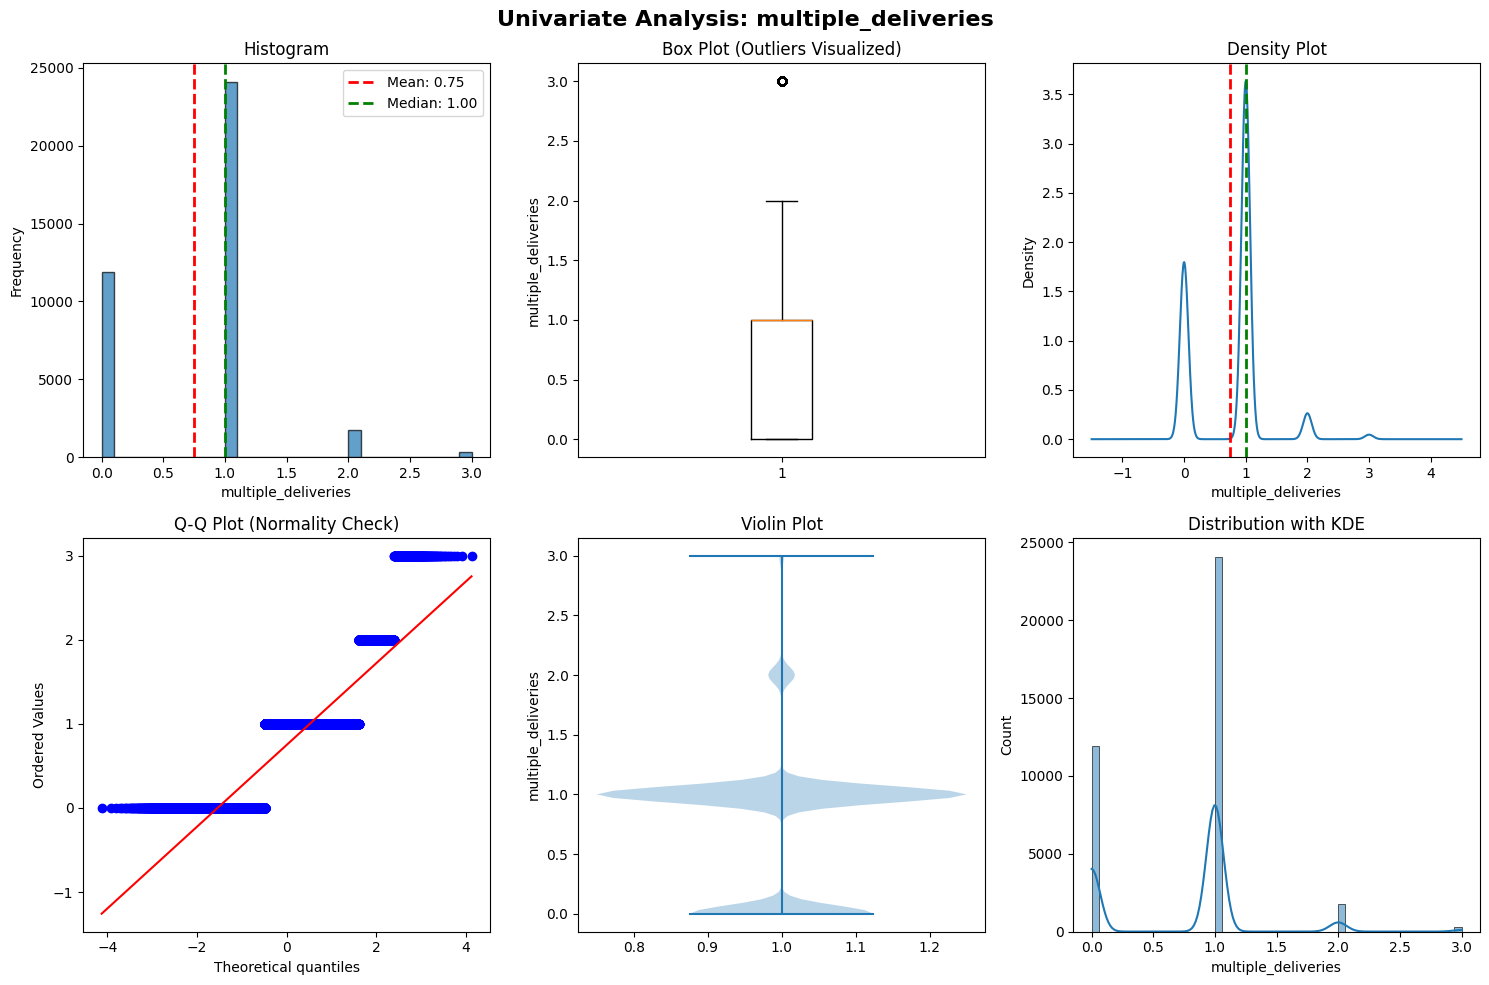


4. RECOMMENDATIONS:
   → Skewness is within acceptable range. No transformation needed.
   → 0.8% outliers present. Consider:
      - Keeping if they represent real extreme values
      - Removing if they are data entry errors
      - Using robust metrics (median, IQR)

--------------------------------------------------

ANALYZING: Time_taken(min)

1. DESCRIPTIVE STATISTICS:
count    38064.000000
mean        26.576109
std          9.330616
min         10.000000
25%         19.000000
50%         26.000000
75%         33.000000
max         54.000000
Name: Time_taken(min), dtype: float64

2. SKEWNESS: 0.472
   → Approximately symmetric

3. OUTLIER DETECTION (IQR method):
   - Lower bound: -2.00
   - Upper bound: 54.00
   - Number of outliers: 0 (0.00%)


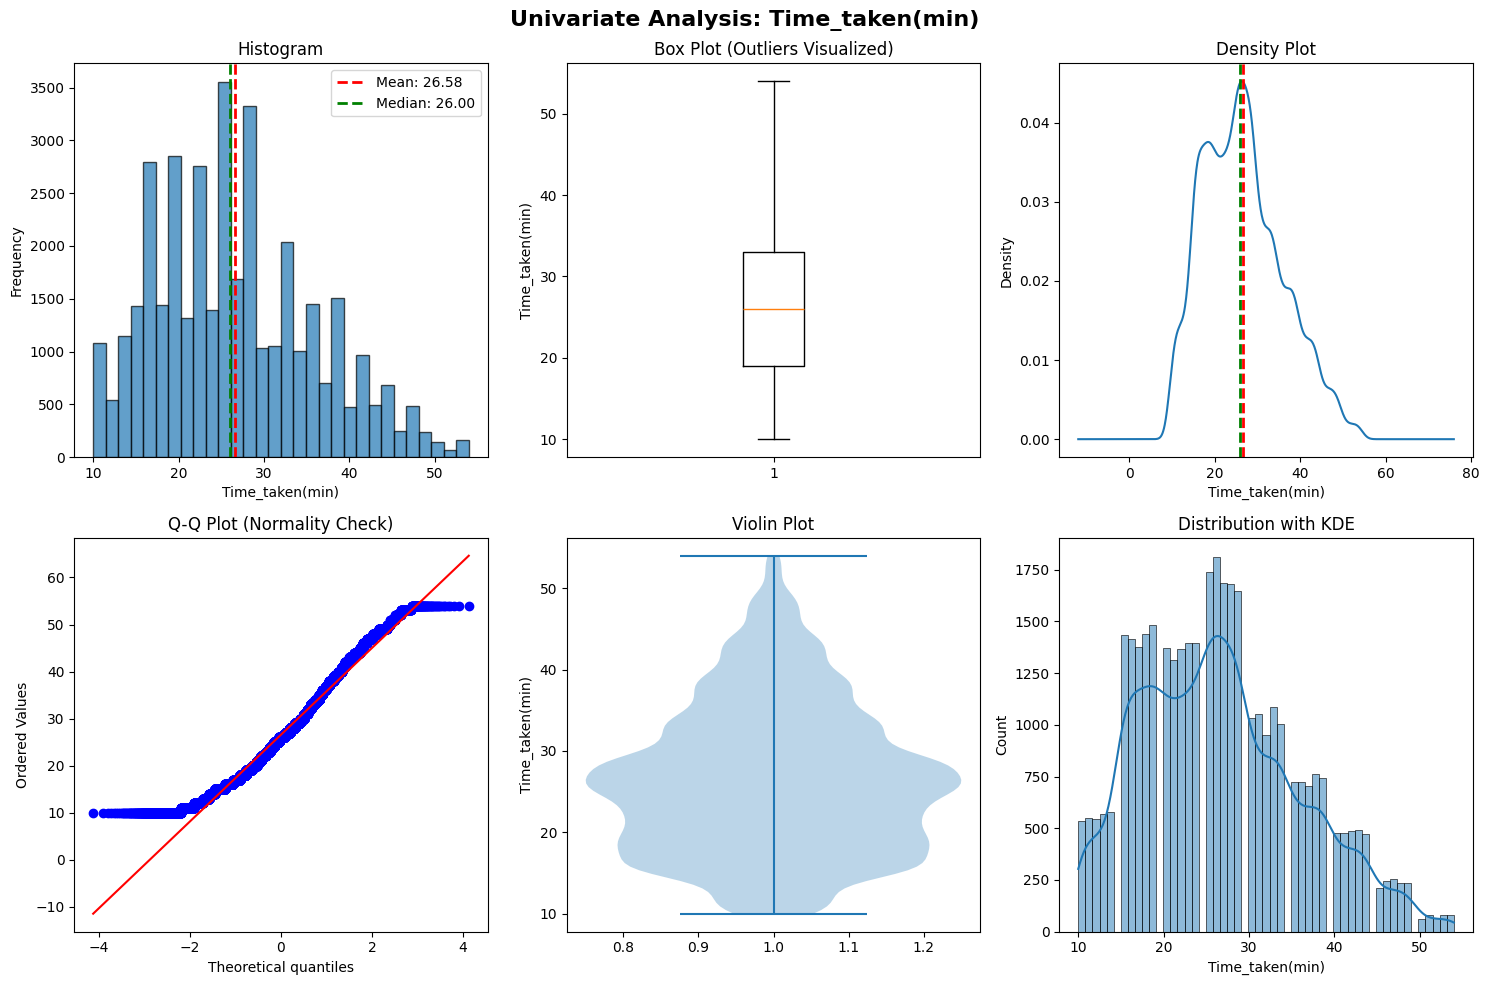


4. RECOMMENDATIONS:
   → Skewness is within acceptable range. No transformation needed.

--------------------------------------------------

OVERALL SUMMARY OF ALL NUMERICAL COLUMNS
                 Column   Count      Mean      Std  Min  25%  50% (Median)  75%  Max  Skewness  Outlier_Count  Outlier_Percentage  Missing_Count  Missing_Percentage
    Delivery_person_Age 38064.0 29.608948 5.761658 20.0 25.0          30.0 35.0 39.0 -0.029069              0            0.000000              0                 0.0
Delivery_person_Ratings 38064.0  4.631870 0.316950  2.5  4.5           4.7  4.9  5.0 -1.771967           1030            2.705969              0                 0.0
    multiple_deliveries 38064.0  0.748818 0.572731  0.0  0.0           1.0  1.0  3.0  0.319784            306            0.803909              0                 0.0
        Time_taken(min) 38064.0 26.576109 9.330616 10.0 19.0          26.0 33.0 54.0  0.472147              0            0.000000              0             

In [7]:
summary = univariate_analysis_numerical(df, num_col)

#### cat cols

UNIVARIATE ANALYSIS FOR CATEGORICAL COLUMNS

Analyzing 9 categorical columns:
Vehicle_condition, City, Festival, Type_of_order, Weatherconditions, multiple_deliveries, Type_of_vehicle, delivery_city, Road_traffic_density

ANALYZING: Vehicle_condition

1. DESCRIPTIVE STATISTICS:
   - Unique values: 3
   - Missing values: 0 (0.00%)
   - Data type: int64

2. FREQUENCY DISTRIBUTION:
 Category  Count  Percentage
        0  12813   33.661728
        2  12633   33.188840
        1  12618   33.149433

3. ANOMALIES/INSIGHTS:


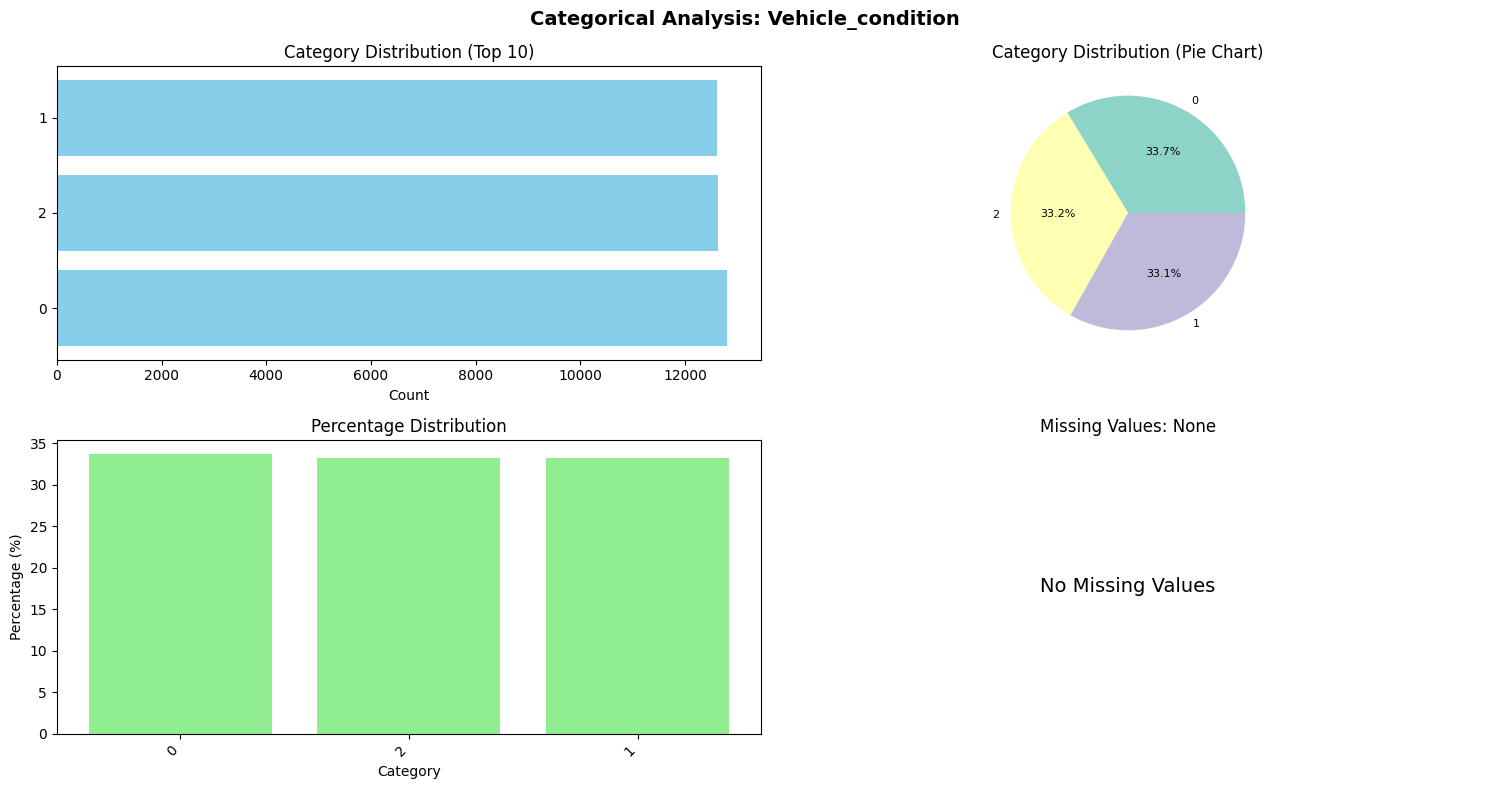


4. RECOMMENDATIONS:

--------------------------------------------------

ANALYZING: City

1. DESCRIPTIVE STATISTICS:
   - Unique values: 3
   - Missing values: 0 (0.00%)
   - Data type: object

2. FREQUENCY DISTRIBUTION:
     Category  Count  Percentage
Metropolitian  29327   77.046553
        Urban   8599   22.590900
   Semi-Urban    138    0.362547

3. ANOMALIES/INSIGHTS:
   ⚠️ Rare categories (<1%): 1 categories
      ['Semi-Urban']
   ⭐ Dominant category (>50%): Metropolitian (77.0%)


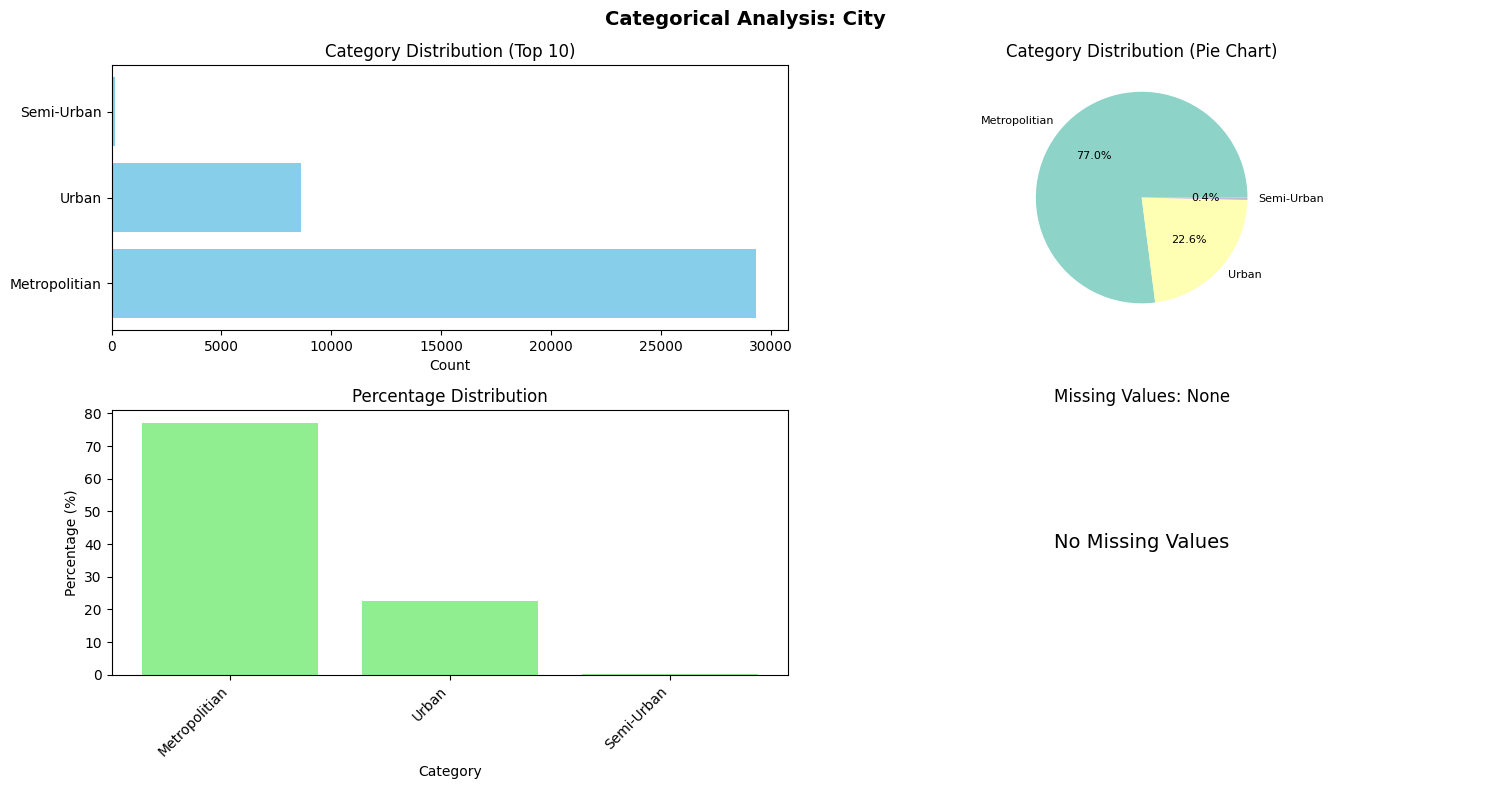


4. RECOMMENDATIONS:
   • Rare categories detected (1 categories with <1%):
     → Consider combining rare categories into 'Other' category

--------------------------------------------------

ANALYZING: Festival

1. DESCRIPTIVE STATISTICS:
   - Unique values: 2
   - Missing values: 0 (0.00%)
   - Data type: object

2. FREQUENCY DISTRIBUTION:
Category  Count  Percentage
      No  37299   97.990227
     Yes    765    2.009773

3. ANOMALIES/INSIGHTS:
   ⭐ Dominant category (>50%): No (98.0%)


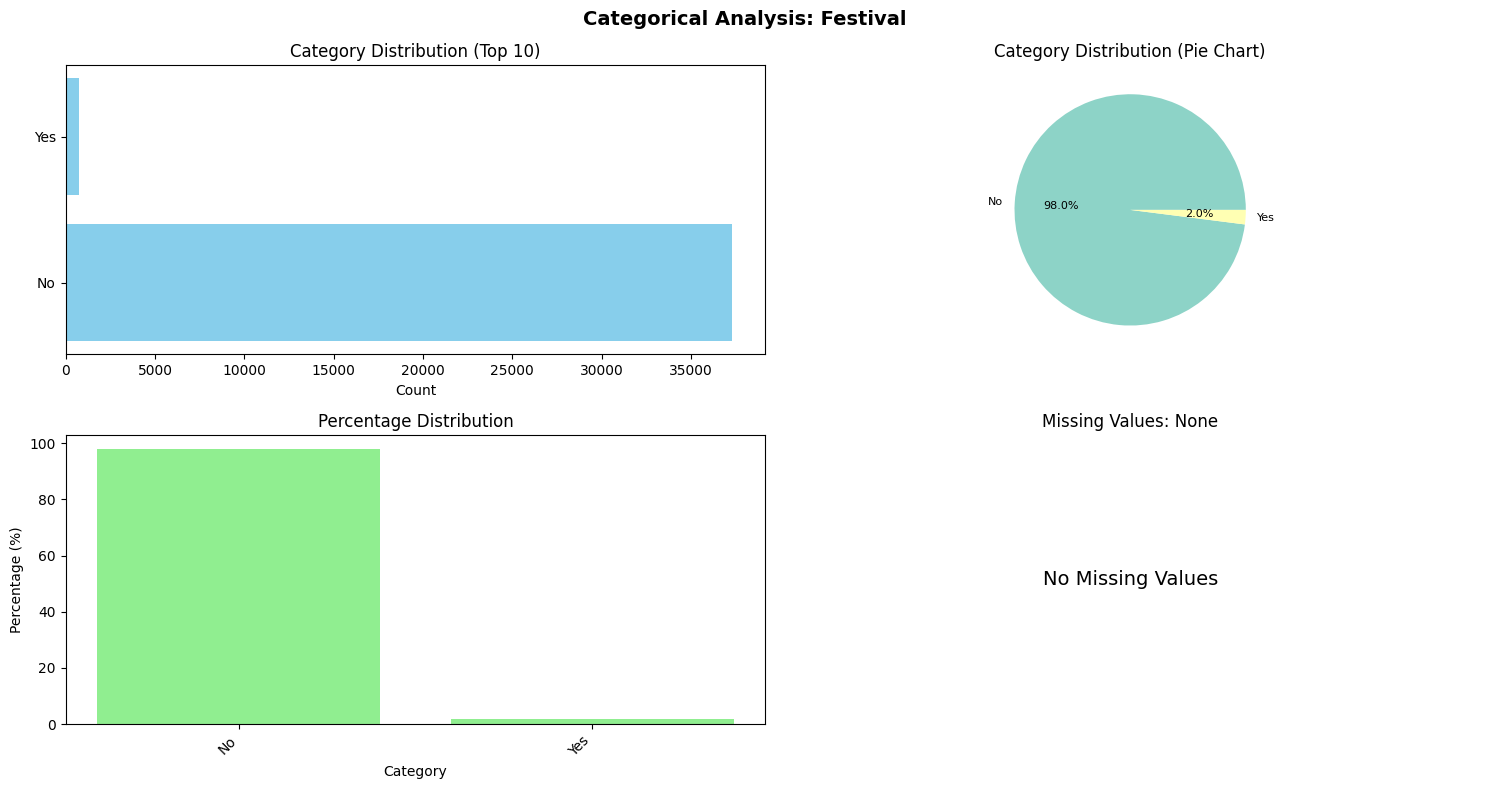


4. RECOMMENDATIONS:

--------------------------------------------------

ANALYZING: Type_of_order

1. DESCRIPTIVE STATISTICS:
   - Unique values: 4
   - Missing values: 0 (0.00%)
   - Data type: object

2. FREQUENCY DISTRIBUTION:
Category  Count  Percentage
  Snack    9577   25.160256
   Meal    9574   25.152375
 Drinks    9514   24.994746
 Buffet    9399   24.692623

3. ANOMALIES/INSIGHTS:


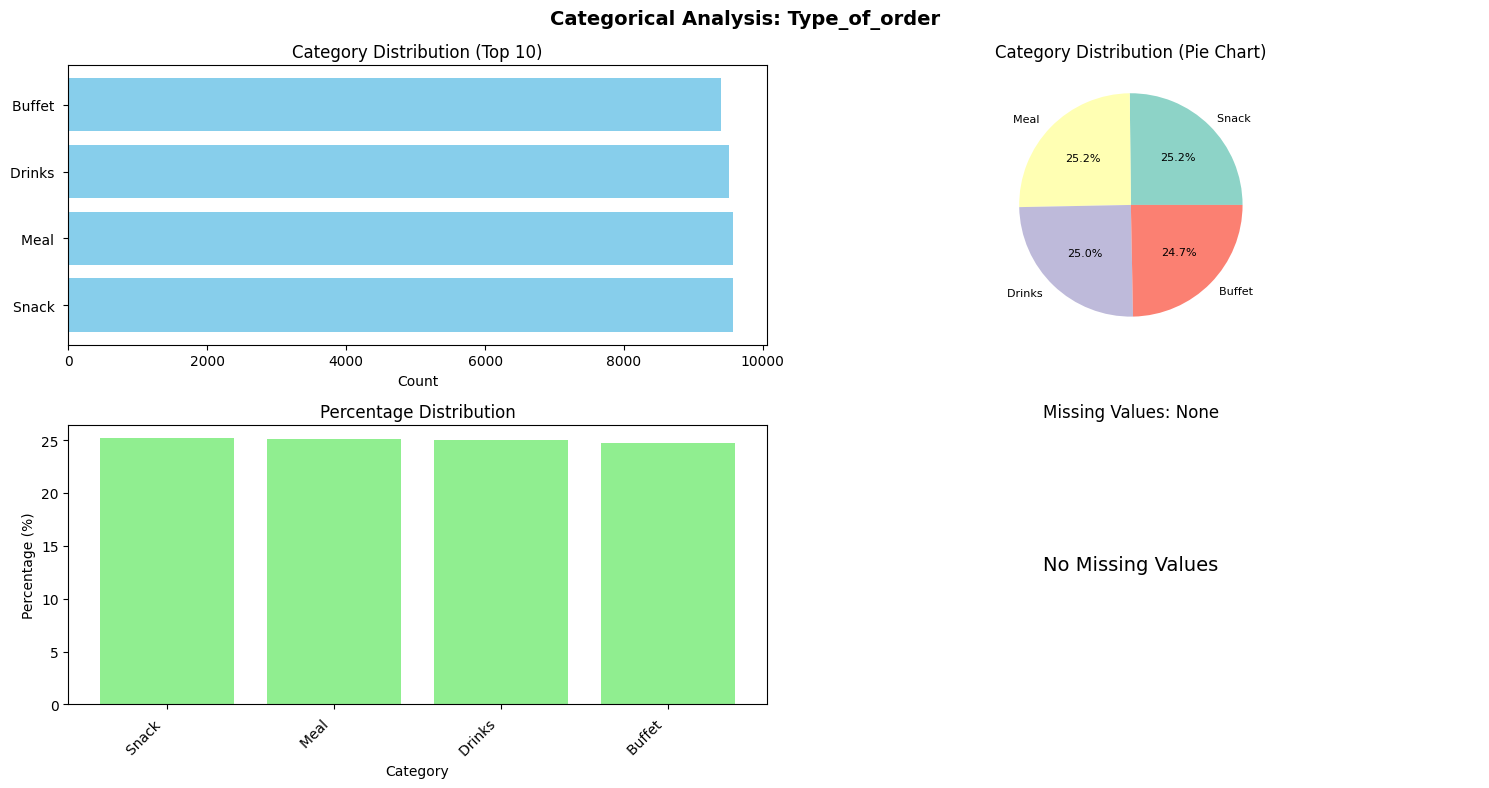


4. RECOMMENDATIONS:

--------------------------------------------------

ANALYZING: Weatherconditions

1. DESCRIPTIVE STATISTICS:
   - Unique values: 6
   - Missing values: 0 (0.00%)
   - Data type: object

2. FREQUENCY DISTRIBUTION:
  Category  Count  Percentage
       Fog   6518   17.123792
    Stormy   6431   16.895229
    Cloudy   6393   16.795397
Sandstorms   6326   16.619378
     Windy   6289   16.522173
     Sunny   6107   16.044031

3. ANOMALIES/INSIGHTS:


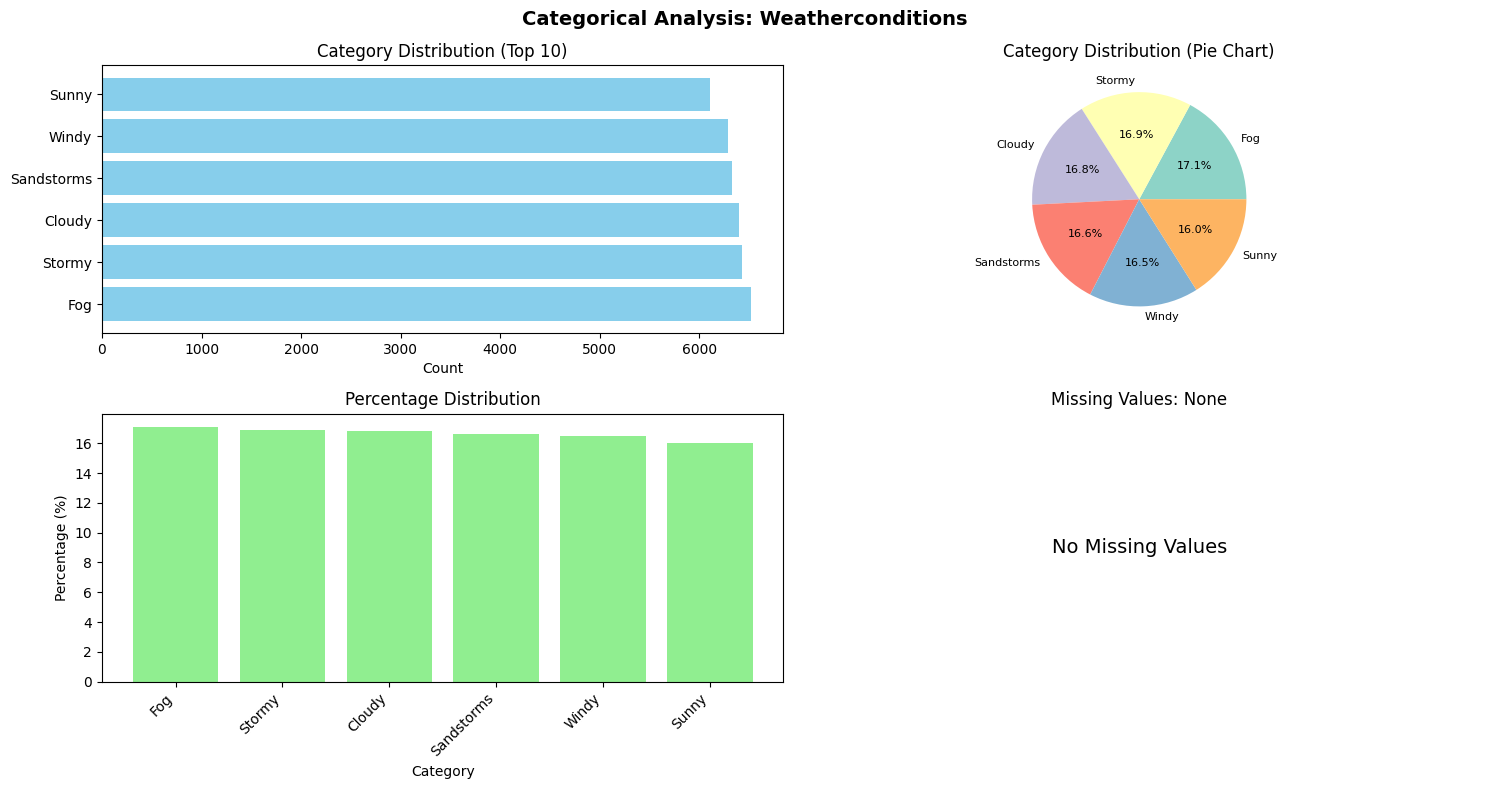


4. RECOMMENDATIONS:

--------------------------------------------------

ANALYZING: multiple_deliveries

1. DESCRIPTIVE STATISTICS:
   - Unique values: 4
   - Missing values: 0 (0.00%)
   - Data type: int64

2. FREQUENCY DISTRIBUTION:
 Category  Count  Percentage
        1  24095   63.301282
        0  11918   31.310425
        2   1745    4.584384
        3    306    0.803909

3. ANOMALIES/INSIGHTS:
   ⚠️ Rare categories (<1%): 1 categories
      [3]
   ⭐ Dominant category (>50%): 1 (63.3%)


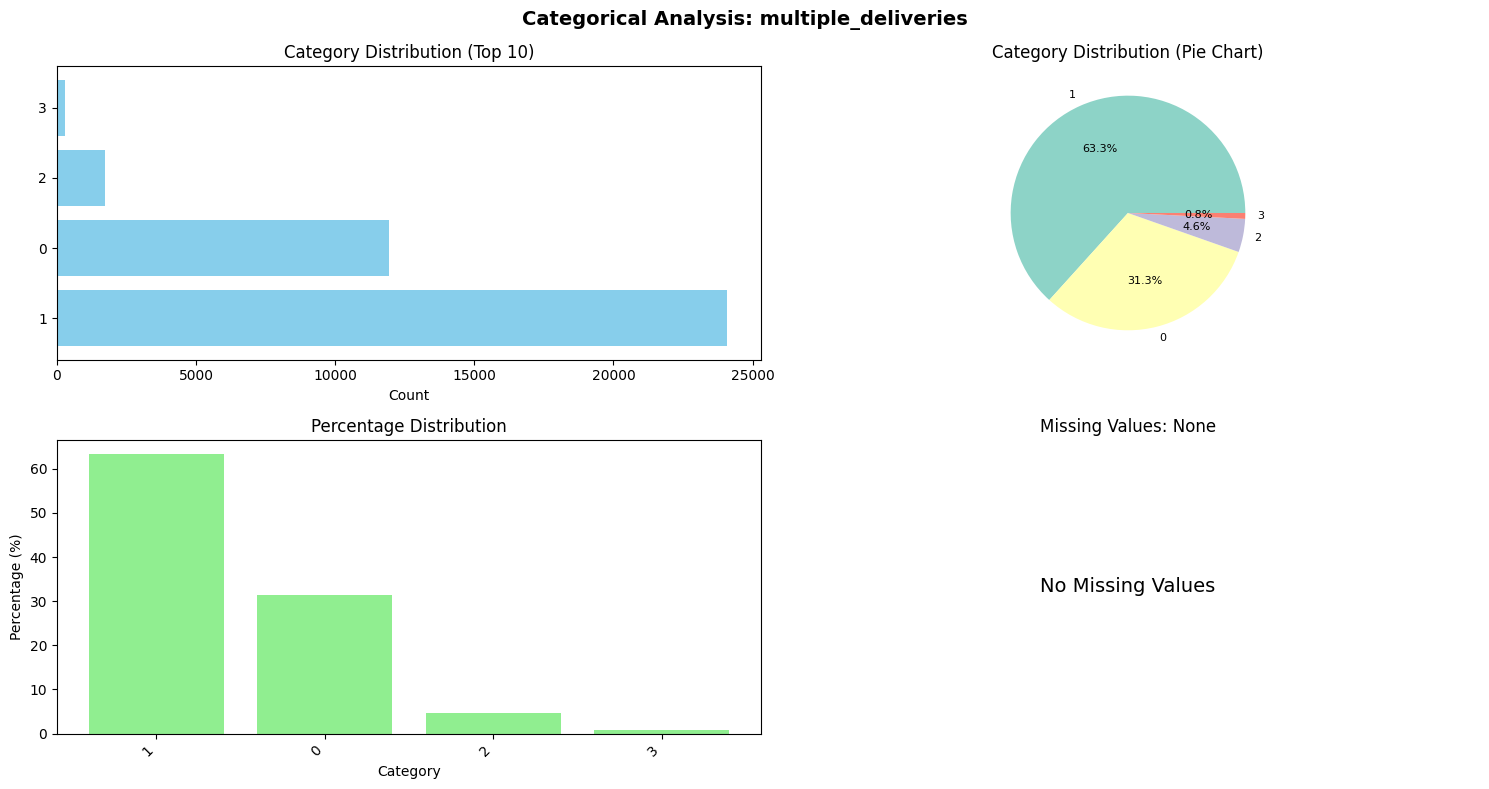


4. RECOMMENDATIONS:
   • Rare categories detected (1 categories with <1%):
     → Consider combining rare categories into 'Other' category

--------------------------------------------------

ANALYZING: Type_of_vehicle

1. DESCRIPTIVE STATISTICS:
   - Unique values: 3
   - Missing values: 0 (0.00%)
   - Data type: object

2. FREQUENCY DISTRIBUTION:
         Category  Count  Percentage
      motorcycle   22433   58.934952
         scooter   12598   33.096889
electric_scooter    3033    7.968159

3. ANOMALIES/INSIGHTS:
   ⭐ Dominant category (>50%): motorcycle  (58.9%)


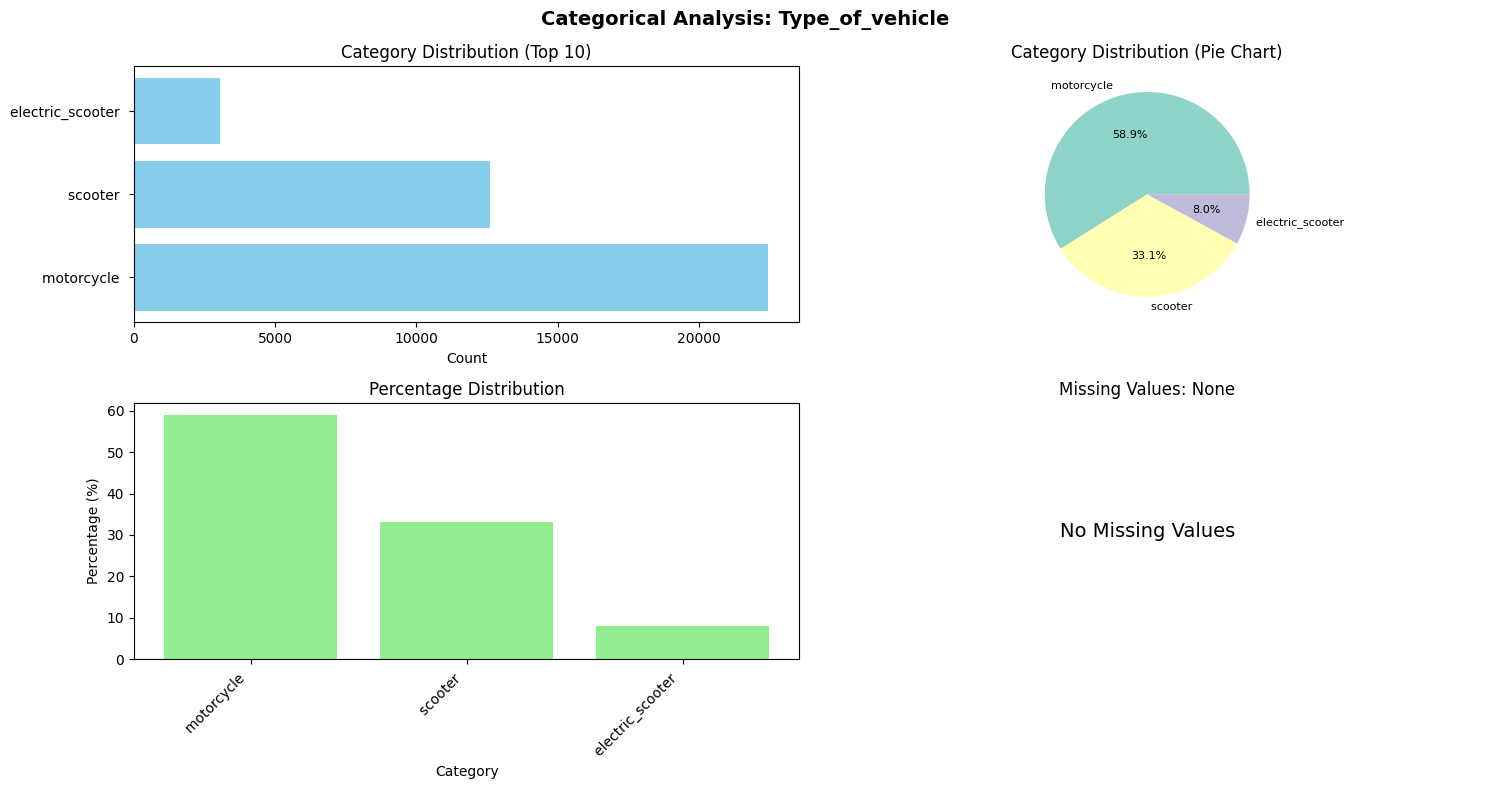


4. RECOMMENDATIONS:

--------------------------------------------------

ANALYZING: delivery_city

1. DESCRIPTIVE STATISTICS:
   - Unique values: 22
   - Missing values: 0 (0.00%)
   - Data type: object

2. FREQUENCY DISTRIBUTION:
  Category  Count  Percentage
  Jabalpur   3137    8.241383
     Surat   2908    7.639765
 Hyderabad   2905    7.631883
Coimbatore   2897    7.610866
    Mumbai   2880    7.566204
 Bangalore   2878    7.560950
    Indore   2860    7.513661
      Pune   2839    7.458491
   Chennai   2835    7.447982
    Mysore   2715    7.132724
    Ranchi   2313    6.076608
  Vadodara   1432    3.762085
   Kolkata    647    1.699769
     Kochi    635    1.668243
  Ludhiana    627    1.647226
    Kanpur    616    1.618327
       Goa    547    1.437053
      Agra    513    1.347730
 Allahabad    511    1.342476
Aurangabad    502    1.318831
  Dehradun    436    1.145439
    Bhilai    431    1.132303

3. ANOMALIES/INSIGHTS:
   🔥 High cardinality: 22 unique values - may need fea

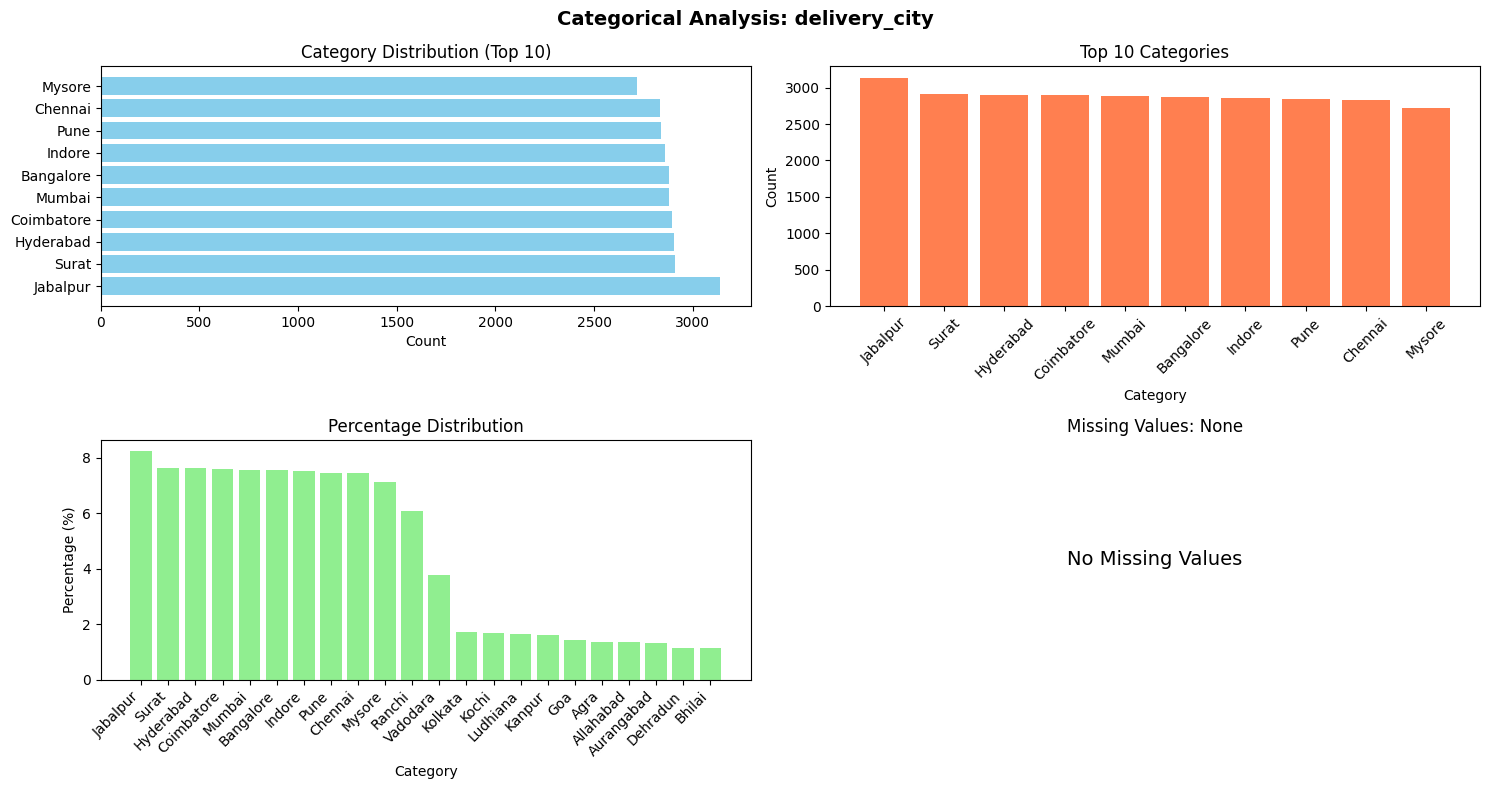


4. RECOMMENDATIONS:
   • High cardinality (22 categories):
     → Consider grouping rare categories into 'Other'
     → Use frequency or target encoding instead of one-hot encoding

--------------------------------------------------

ANALYZING: Road_traffic_density

1. DESCRIPTIVE STATISTICS:
   - Unique values: 4
   - Missing values: 0 (0.00%)
   - Data type: object

2. FREQUENCY DISTRIBUTION:
Category  Count  Percentage
    Low   12831   33.709016
    Jam   12140   31.893653
 Medium    9326   24.500841
   High    3767    9.896490

3. ANOMALIES/INSIGHTS:


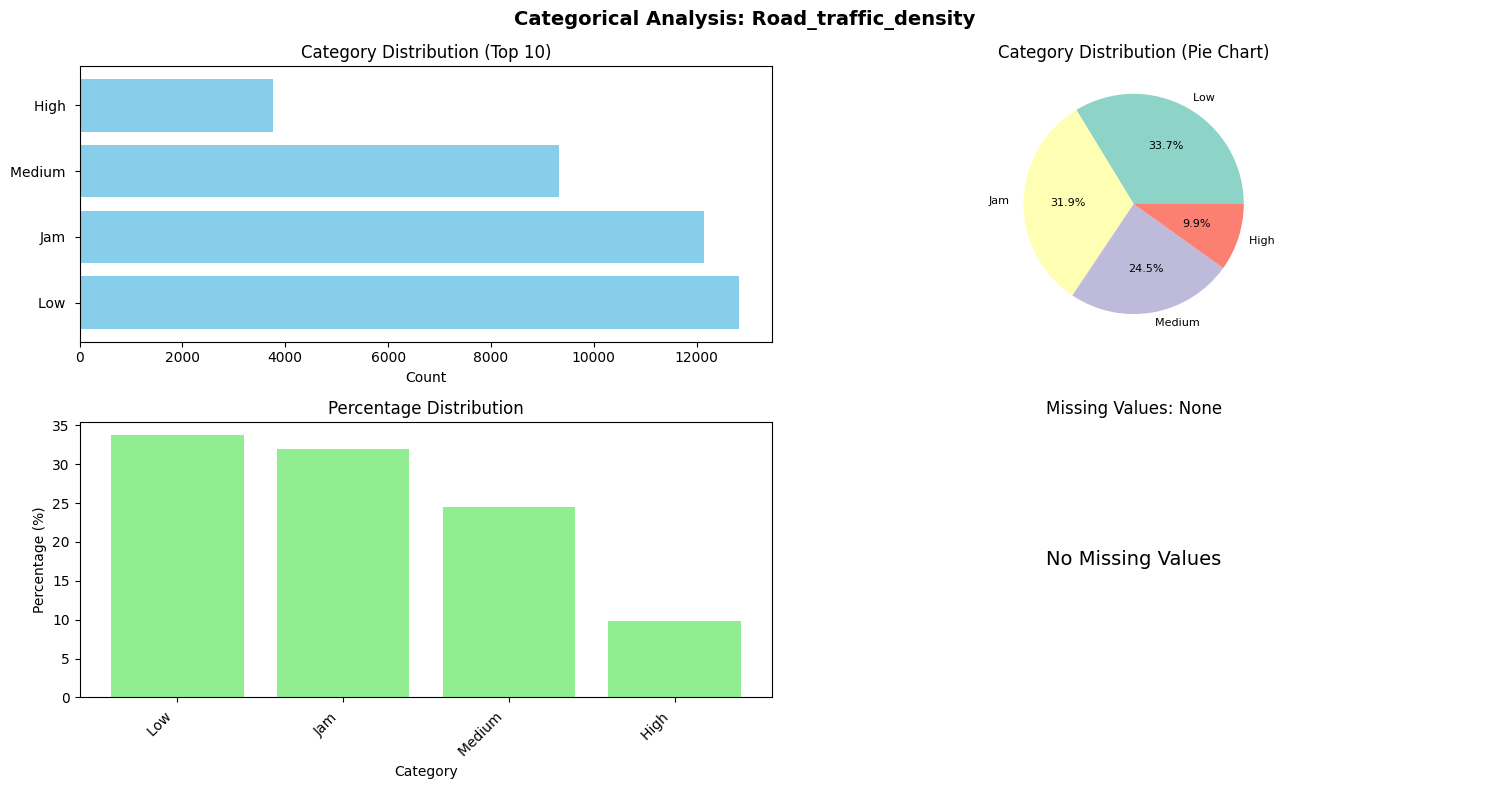


4. RECOMMENDATIONS:

--------------------------------------------------

OVERALL SUMMARY OF CATEGORICAL COLUMNS
              Column Data_Type  Unique_Values Most_Frequent  Most_Freq_Count  Most_Freq_Pct  Missing_Count  Missing_Pct  Has_Rare_Categories  Cardinality_Issue
   Vehicle_condition     int64              3             0            12813      33.661728              0          0.0                False              False
                City    object              3 Metropolitian            29327      77.046553              0          0.0                 True              False
            Festival    object              2            No            37299      97.990227              0          0.0                False              False
       Type_of_order    object              4        Snack              9577      25.160256              0          0.0                False              False
   Weatherconditions    object              6           Fog             6518      17.12

In [8]:
summary1 = univariate_analysis_categorical(df, cat_col)

### 3. Cleaning after EDA

In [9]:
# Drop delivery_city column
if 'delivery_city' in df.columns:
    df.drop(columns=['delivery_city'], inplace=True)
    print("✓ Removed delivery_city")

✓ Removed delivery_city


In [10]:
def handle_festival_column(df):
    """
    Properly handle the Festival column - fix corruption or reconstruct
    """
    
    print("\n=== Fixing Festival Column ===")
    
    # Check current state
    print(f"Current data type: {df['Festival'].dtype}")
    print(f"Number of unique values: {df['Festival'].nunique()}")
    
    # Sample first few values
    sample_values = df['Festival'].head(3).tolist()
    print(f"Sample values: {sample_values}")
    
    # Check if values are extremely long (concatenated)
    if len(sample_values) > 0 and isinstance(sample_values[0], str):
        value_length = len(sample_values[0])
        print(f"Length of first value: {value_length}")
        
        if value_length > 10:
            print("⚠️ Detected corrupted Festival column (concatenated strings)")
            
            # Try to extract valid values
            # Check what the pattern is
            if 'Yes' in sample_values[0]:
                df['Festival'] = 'Yes'
                print("Extracted 'Yes' from corrupted data")
            elif 'No' in sample_values[0]:
                df['Festival'] = 'No'
                print("Extracted 'No' from corrupted data")
            
            # Or use regex to extract
            df['Festival'] = df['Festival'].str.extract(r'(Yes|No)')[0]
    
    # Clean the column
    df['Festival'] = df['Festival'].astype(str).str.strip()
    
    # Remove any NaN or invalid values
    df['Festival'] = df['Festival'].replace(['nan', 'NaN', 'None', ''], pd.NA)
    
    # Drop rows with invalid values
    before = len(df)
    df = df[df['Festival'].isin(['Yes', 'No'])]
    after = len(df)
    
    print(f"Rows before: {before}, after: {after}")
    print(f"Dropped {before - after} rows with invalid Festival values")
    
    # Convert to binary
    if df['Festival'].notna().any():
        df['Festival'] = df['Festival'].map({'No': 0, 'Yes': 1})
        print(f"✓ Converted to binary: {df['Festival'].value_counts().to_dict()}")
    else:
        print("⚠️ No valid Festival values found - dropping column")
        df.drop(columns=['Festival'], inplace=True)
    
    return df

# Apply the fix
df = handle_festival_column(df)


=== Fixing Festival Column ===
Current data type: object
Number of unique values: 2
Sample values: ['No', 'No', 'No']
Length of first value: 2
Rows before: 38064, after: 38064
Dropped 0 rows with invalid Festival values
✓ Converted to binary: {0: 37299, 1: 765}


In [11]:
# Check variance in Festival
print("\nFestival distribution:")
print(df['Festival'].value_counts())

# If it's constant or nearly constant, drop it
if df['Festival'].nunique() <= 1 or df['Festival'].mean() < 0.05:
    df.drop(columns=['Festival'], inplace=True)
    print("✓ Removed Festival (low variance)")
else:
    print("Keeping Festival - useful for prediction")


Festival distribution:
Festival
0    37299
1      765
Name: count, dtype: int64
✓ Removed Festival (low variance)


In [12]:
print("\nBefore merging Type_of_vehicle:")
print(df['Type_of_vehicle'].value_counts())

# Merge scooter and electric_scooter
df['Type_of_vehicle_merged'] = df['Type_of_vehicle'].str.replace(
    'electric_scooter', 'scooter', regex=False
)


Before merging Type_of_vehicle:
Type_of_vehicle
motorcycle           22433
scooter              12598
electric_scooter      3033
Name: count, dtype: int64


In [13]:
df['Type_of_vehicle_merged'].value_counts()

Type_of_vehicle_merged
motorcycle     22433
scooter        15631
Name: count, dtype: int64

### 4. Mix Columns

In [14]:
mix_col

['ID',
 'Delivery_person_ID',
 'Restaurant_latitude',
 'Restaurant_longitude',
 'Delivery_location_latitude',
 'Delivery_location_longitude',
 'Order_Date',
 'Time_Orderd',
 'Time_Order_picked']

In [15]:
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2

def calculate_distance(lat1, lon1, lat2, lon2):
    """Calculate distance between two coordinates in km"""
    try:
        R = 6371
        lat1, lon1, lat2, lon2 = map(radians, [float(lat1), float(lon1), float(lat2), float(lon2)])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        return R * c
    except:
        return np.nan

# 1. Calculate delivery distance
print("Calculating delivery distance...")
df['delivery_distance_km'] = df.apply(
    lambda row: calculate_distance(
        row['Restaurant_latitude'], row['Restaurant_longitude'],
        row['Delivery_location_latitude'], row['Delivery_location_longitude']
    ), axis=1
)
print(f"✓ Added delivery_distance_km (mean: {df['delivery_distance_km'].mean():.2f} km)")

# 2. Extract order_hour from Time_Orderd FIRST
print("\nExtracting order_hour...")
# Convert Time_Orderd to datetime if it's not already
if df['Time_Orderd'].dtype == 'object':
    df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], errors='coerce')

# Extract hour
df['order_hour'] = df['Time_Orderd'].dt.hour
print(f"✓ Created order_hour column")
print(f"  Hours range: {df['order_hour'].min()} to {df['order_hour'].max()}")

# 3. Extract features from Order_Date
print("\nProcessing Order_Date...")
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['order_day_of_week'] = df['Order_Date'].dt.dayofweek
df['order_month'] = df['Order_Date'].dt.month
df['is_weekend'] = (df['order_day_of_week'] >= 5).astype(int)
print("✓ Extracted date features")

# 4. Calculate preparation time
print("\nCalculating preparation time...")
if 'Time_Order_picked' in df.columns:
    # Convert to datetime if needed
    if df['Time_Order_picked'].dtype == 'object':
        df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'], errors='coerce')
    
    # Calculate preparation time
    df['prep_time_minutes'] = (df['Time_Order_picked'] - df['Time_Orderd']).dt.total_seconds() / 60
    df.loc[df['prep_time_minutes'] < 0, 'prep_time_minutes'] = np.nan
    print(f"✓ Added prep_time_minutes (mean: {df['prep_time_minutes'].mean():.1f} minutes)")

# 5. Create rush hour flag (NOW order_hour exists)
print("\nCreating rush hour flag...")
df['is_rush_hour'] = (df['order_hour'].between(12, 14) | df['order_hour'].between(19, 21)).astype(int)
print(f"✓ Added is_rush_hour")
print(f"  Rush hour orders: {df['is_rush_hour'].sum()} ({df['is_rush_hour'].mean()*100:.1f}%)")

# 6. Drop unnecessary columns
columns_to_drop = []
for col in ['ID', 'Delivery_person_ID', 'Restaurant_latitude', 'Restaurant_longitude',
            'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date',
            'Time_Orderd', 'Time_Order_picked', 'order_minute']:
    if col in df.columns:
        columns_to_drop.append(col)

df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

print(f"\n✓ Dropped {len(columns_to_drop)} columns")
print(f"\nFinal columns ({len(df.columns)}):")
for col in df.columns:
    print(f"  - {col}")

Calculating delivery distance...
✓ Added delivery_distance_km (mean: 28.38 km)

Extracting order_hour...


C:\Users\iampr\AppData\Local\Temp\ipykernel_22652\2555412879.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], errors='coerce')
C:\Users\iampr\AppData\Local\Temp\ipykernel_22652\2555412879.py:41: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')


✓ Created order_hour column
  Hours range: 0 to 23

Processing Order_Date...
✓ Extracted date features

Calculating preparation time...


C:\Users\iampr\AppData\Local\Temp\ipykernel_22652\2555412879.py:52: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'], errors='coerce')


✓ Added prep_time_minutes (mean: 9.9 minutes)

Creating rush hour flag...
✓ Added is_rush_hour
  Rush hour orders: 14322 (37.6%)

✓ Dropped 9 columns

Final columns (18):
  - Delivery_person_Age
  - Delivery_person_Ratings
  - Weatherconditions
  - Road_traffic_density
  - Vehicle_condition
  - Type_of_order
  - Type_of_vehicle
  - multiple_deliveries
  - City
  - Time_taken(min)
  - Type_of_vehicle_merged
  - delivery_distance_km
  - order_hour
  - order_day_of_week
  - order_month
  - is_weekend
  - prep_time_minutes
  - is_rush_hour


In [16]:
df.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'City', 'Time_taken(min)',
       'Type_of_vehicle_merged', 'delivery_distance_km', 'order_hour',
       'order_day_of_week', 'order_month', 'is_weekend', 'prep_time_minutes',
       'is_rush_hour'],
      dtype='object')

### 5. Bivariate Analysis

In [17]:
num_col = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries', 
           'Time_taken(min)', 'delivery_distance_km', 'prep_time_minutes']

cat_col = ['Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 
           'Type_of_order', 'City', 'Type_of_vehicle', 'Type_of_vehicle_merged', 
           'order_day_of_week', 'order_month', 'order_hour', 'is_weekend', 'is_rush_hour']

target_col = 'Time_taken(min)'

🎯 BIVARIATE ANALYSIS WITH TARGET: Time_taken(min)

📈 NUMERICAL FEATURES vs TARGET

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: Delivery_person_Age → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


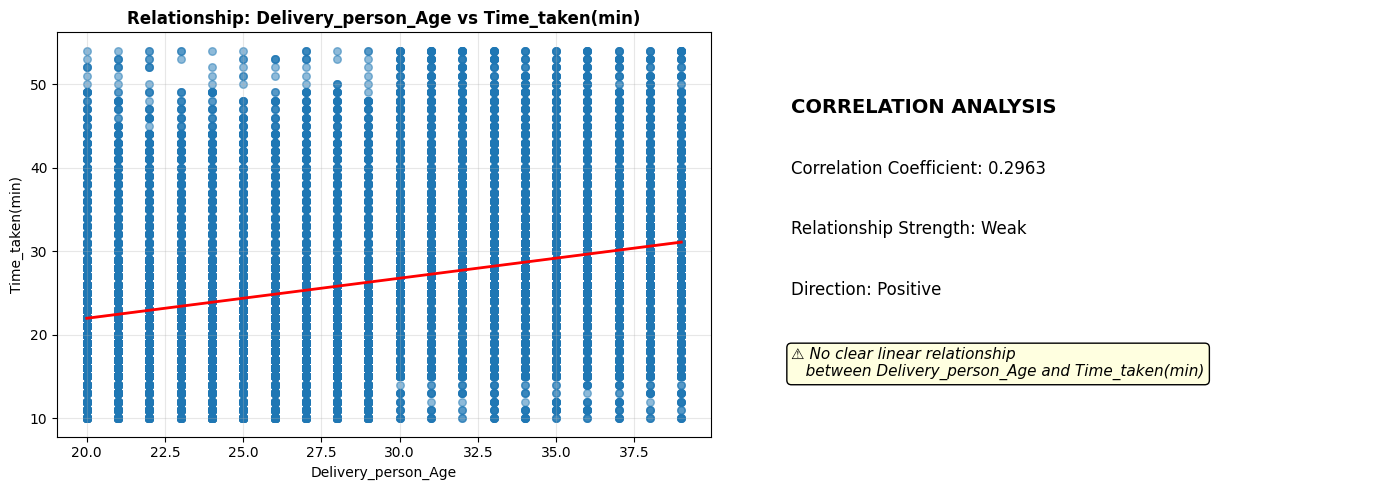


📊 Statistics:
   • Delivery_person_Age - Mean: 29.61, Std: 5.76
   • Time_taken(min) - Mean: 26.58, Std: 9.33

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: Delivery_person_Ratings → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


d:\Swiggy-Delivery-Time-Prediction\experiment\utils.py:504: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Swiggy-Delivery-Time-Prediction\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


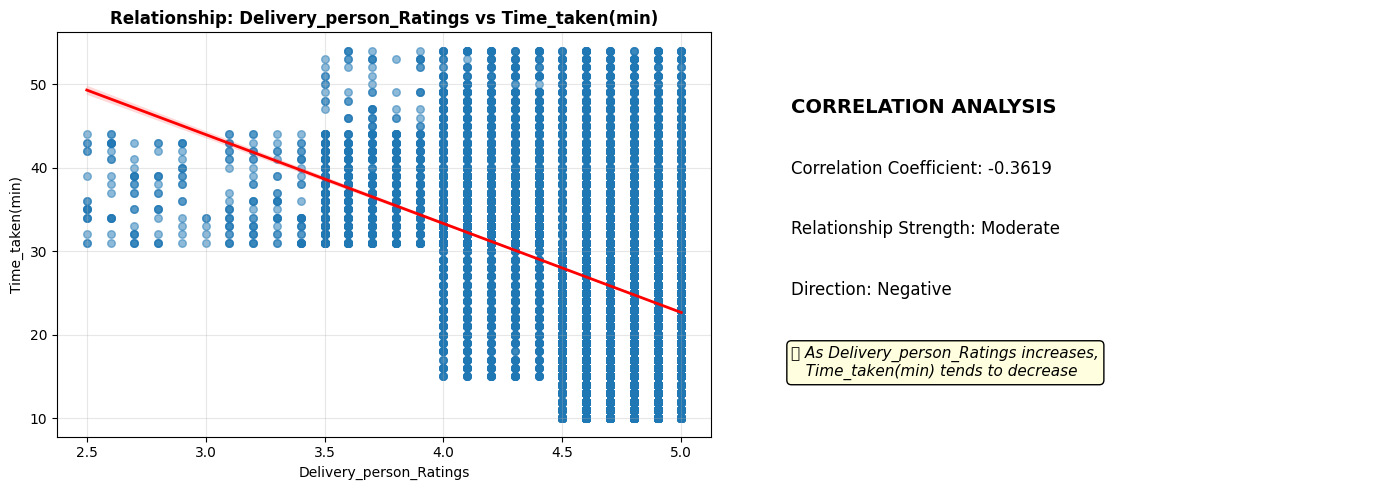


📊 Statistics:
   • Delivery_person_Ratings - Mean: 4.63, Std: 0.32
   • Time_taken(min) - Mean: 26.58, Std: 9.33

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: multiple_deliveries → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


d:\Swiggy-Delivery-Time-Prediction\experiment\utils.py:504: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Swiggy-Delivery-Time-Prediction\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


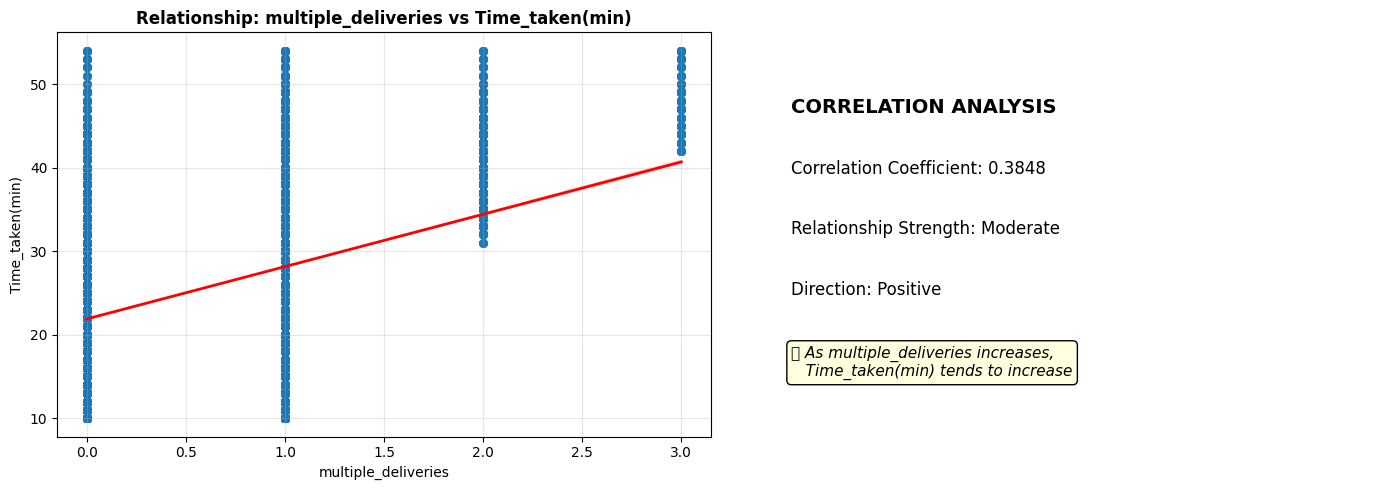


📊 Statistics:
   • multiple_deliveries - Mean: 0.75, Std: 0.57
   • Time_taken(min) - Mean: 26.58, Std: 9.33

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: delivery_distance_km → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


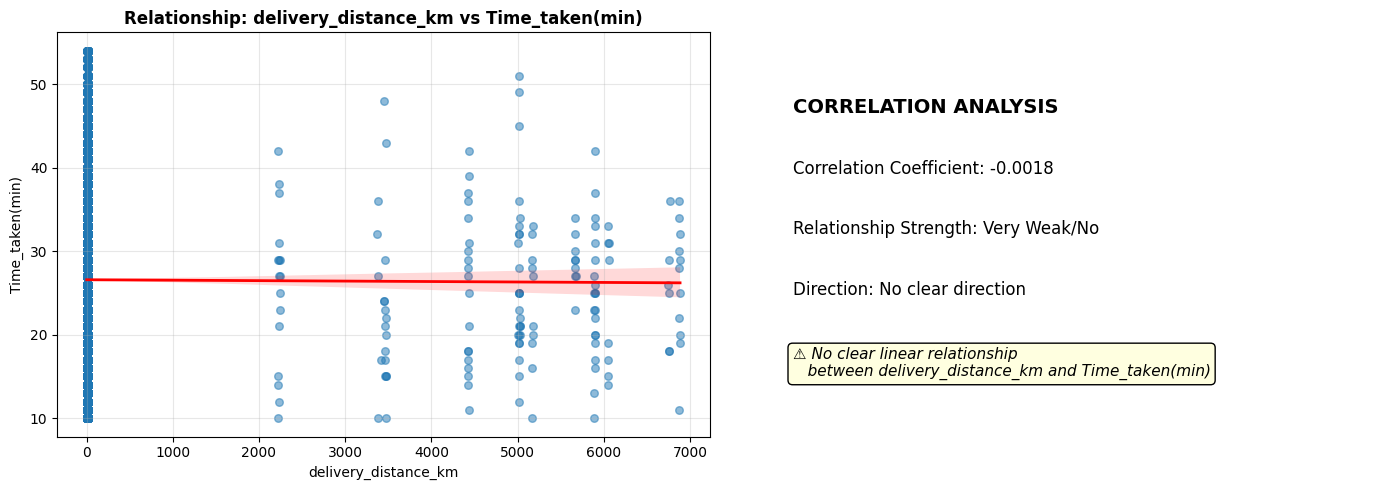


📊 Statistics:
   • delivery_distance_km - Mean: 28.38, Std: 311.43
   • Time_taken(min) - Mean: 26.58, Std: 9.33

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: prep_time_minutes → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


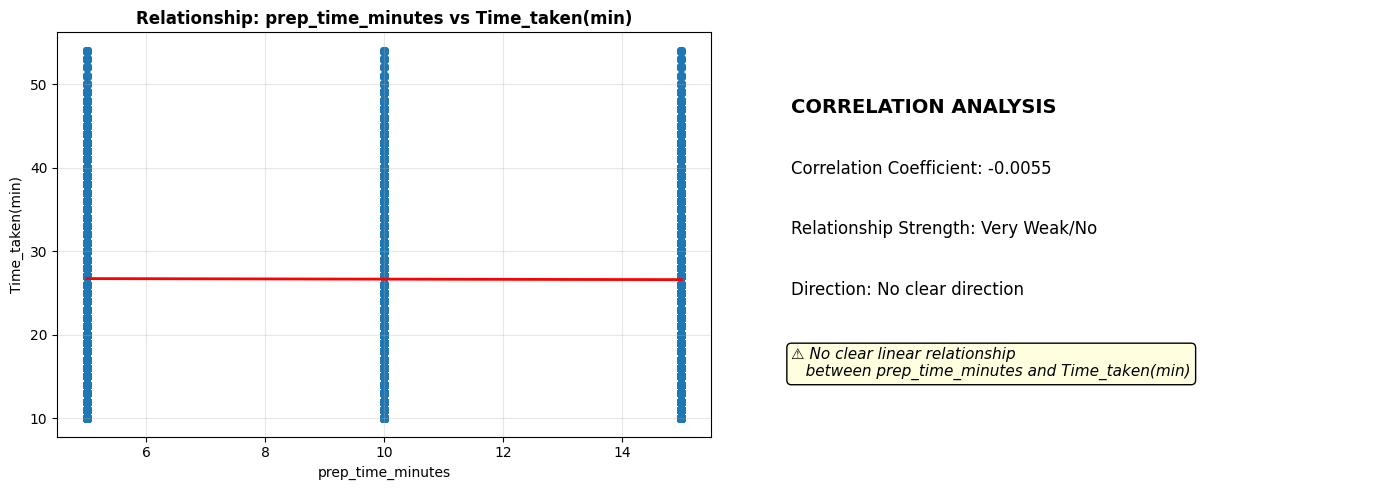


📊 Statistics:
   • prep_time_minutes - Mean: 9.95, Std: 4.08
   • Time_taken(min) - Mean: 26.58, Std: 9.33

📊 CATEGORICAL FEATURES vs TARGET

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: Weatherconditions → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


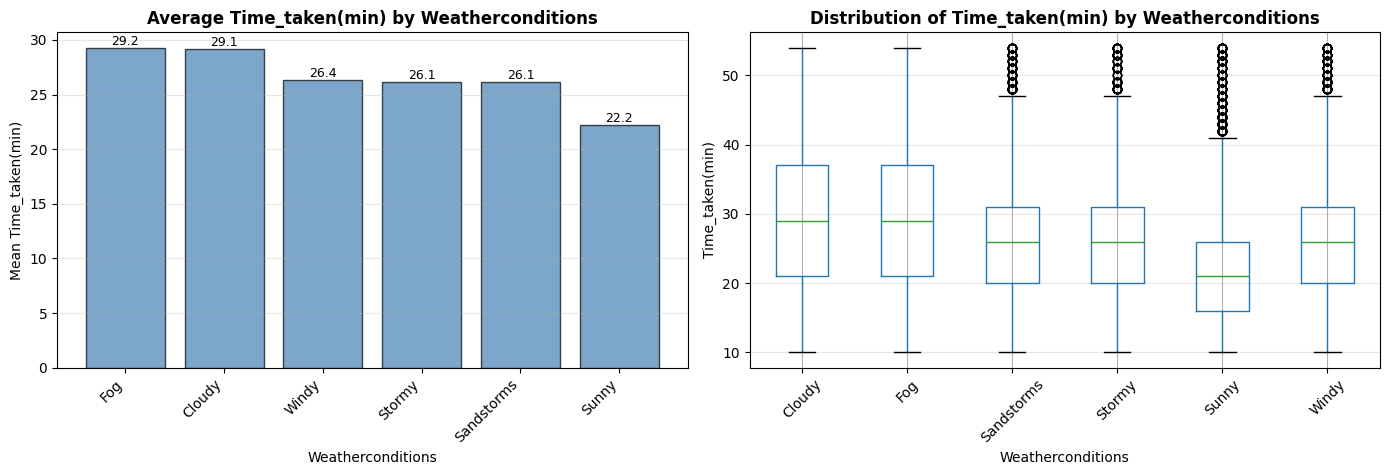


📊 Summary Statistics (sorted by mean Time_taken(min)):
                    mean  median  count    std
Weatherconditions                             
Fog                29.23    29.0   6518  10.10
Cloudy             29.15    29.0   6393   9.97
Windy              26.37    26.0   6289   8.54
Stormy             26.14    26.0   6431   8.43
Sandstorms         26.13    26.0   6326   8.57
Sunny              22.18    21.0   6107   8.35

💡 Key Insight:
   • Best category: 'Fog' (Avg Time_taken(min): 29.23)
   • Worst category: 'Sunny' (Avg Time_taken(min): 22.18)
   • Difference: 7.05

📈 Statistical Significance (ANOVA):
   • F-statistic: 511.1045
   • p-value: 0.0000
   • ✅ Weatherconditions has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: Road_traffic_density → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


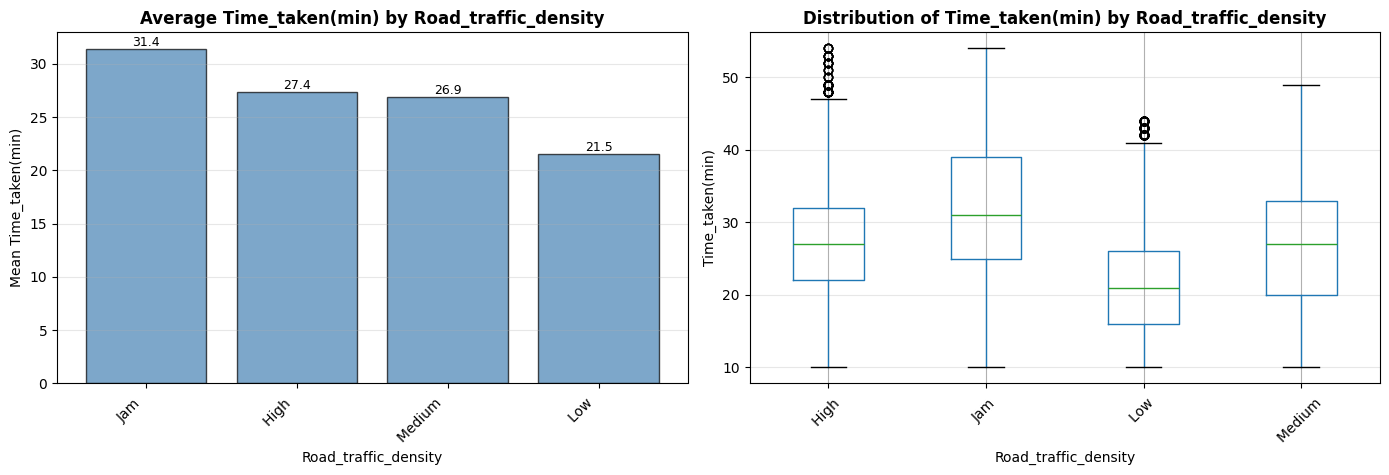


📊 Summary Statistics (sorted by mean Time_taken(min)):
                       mean  median  count   std
Road_traffic_density                            
Jam                   31.40    31.0  12140  9.84
High                  27.39    27.0   3767  8.31
Medium                26.93    27.0   9326  8.47
Low                   21.51    21.0  12831  6.80

💡 Key Insight:
   • Best category: 'Jam ' (Avg Time_taken(min): 31.40)
   • Worst category: 'Low ' (Avg Time_taken(min): 21.51)
   • Difference: 9.89

📈 Statistical Significance (ANOVA):
   • F-statistic: 2895.9441
   • p-value: 0.0000
   • ✅ Road_traffic_density has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: Vehicle_condition → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


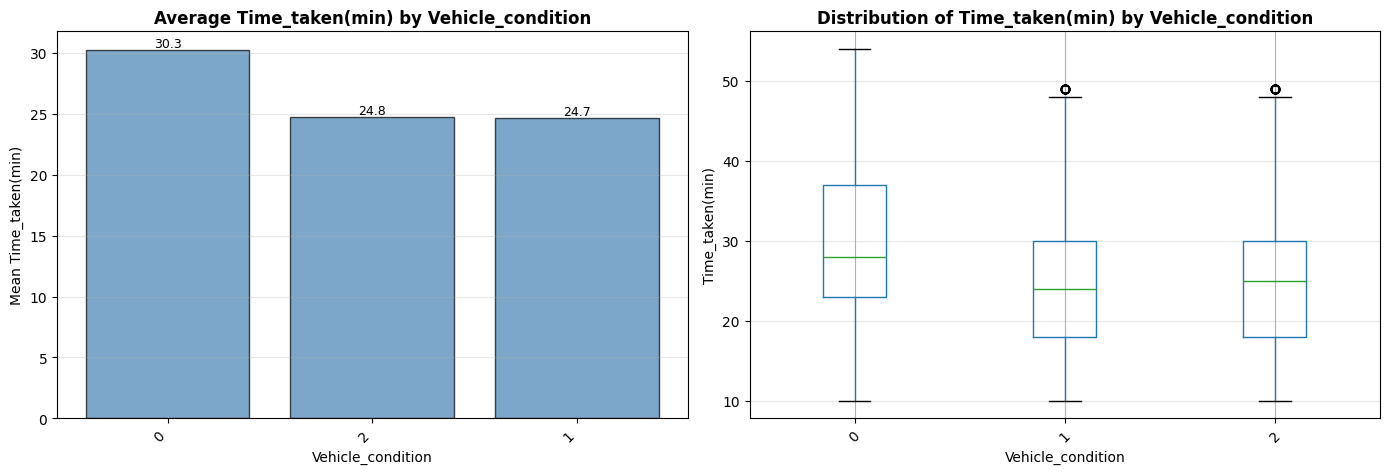


📊 Summary Statistics (sorted by mean Time_taken(min)):
                    mean  median  count   std
Vehicle_condition                            
0                  30.26    28.0  12813  9.55
2                  24.76    25.0  12633  8.61
1                  24.66    24.0  12618  8.66

💡 Key Insight:
   • Best category: '0' (Avg Time_taken(min): 30.26)
   • Worst category: '1' (Avg Time_taken(min): 24.66)
   • Difference: 5.60

📈 Statistical Significance (ANOVA):
   • F-statistic: 1635.4537
   • p-value: 0.0000
   • ✅ Vehicle_condition has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: Type_of_order → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


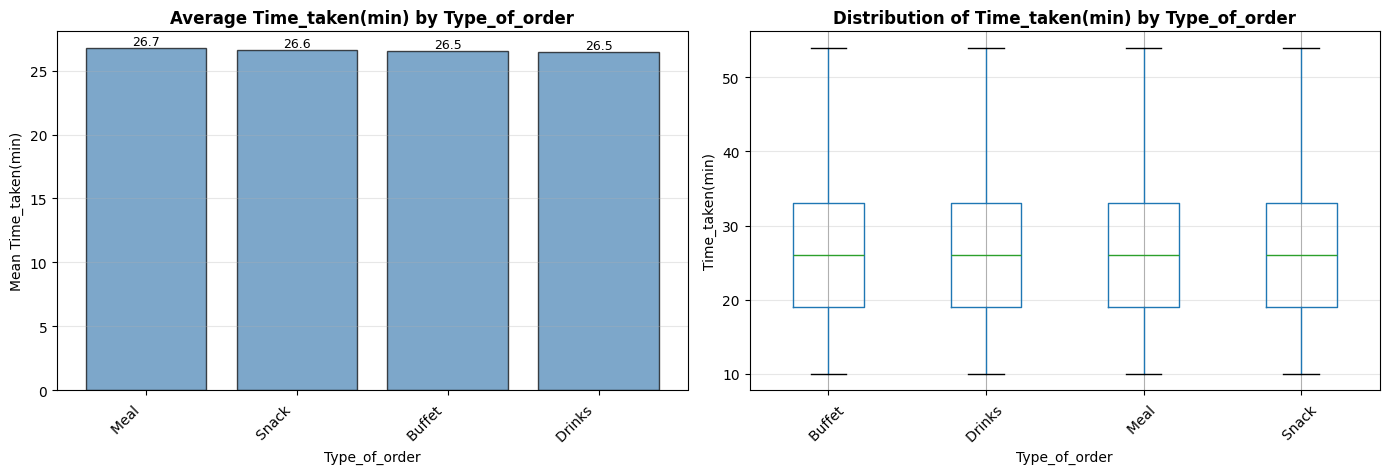


📊 Summary Statistics (sorted by mean Time_taken(min)):
                mean  median  count   std
Type_of_order                            
Meal           26.74    26.0   9574  9.38
Snack          26.58    26.0   9577  9.35
Buffet         26.50    26.0   9399  9.34
Drinks         26.48    26.0   9514  9.24

💡 Key Insight:
   • Best category: 'Meal ' (Avg Time_taken(min): 26.74)
   • Worst category: 'Drinks ' (Avg Time_taken(min): 26.48)
   • Difference: 0.26

📈 Statistical Significance (ANOVA):
   • F-statistic: 1.5656
   • p-value: 0.1954
   • ❌ Type_of_order does NOT have significant impact on Time_taken(min)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: City → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


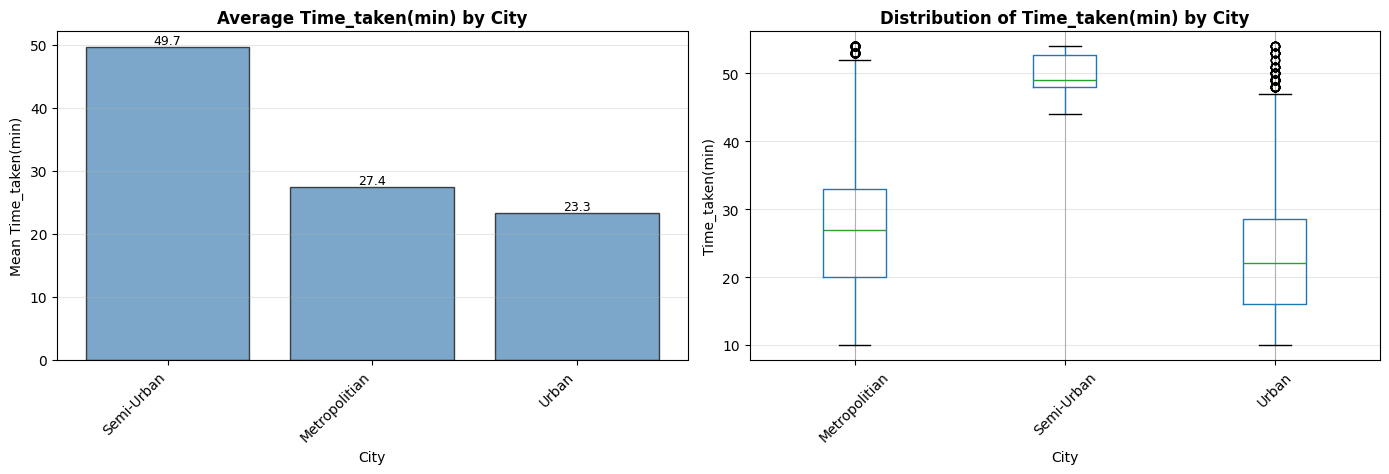


📊 Summary Statistics (sorted by mean Time_taken(min)):
                mean  median  count   std
City                                     
Semi-Urban     49.67    49.0    138  2.77
Metropolitian  27.44    27.0  29327  9.14
Urban          23.26    22.0   8599  8.86

💡 Key Insight:
   • Best category: 'Semi-Urban' (Avg Time_taken(min): 49.67)
   • Worst category: 'Urban' (Avg Time_taken(min): 23.26)
   • Difference: 26.41

📈 Statistical Significance (ANOVA):
   • F-statistic: 1159.4321
   • p-value: 0.0000
   • ✅ City has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: Type_of_vehicle → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


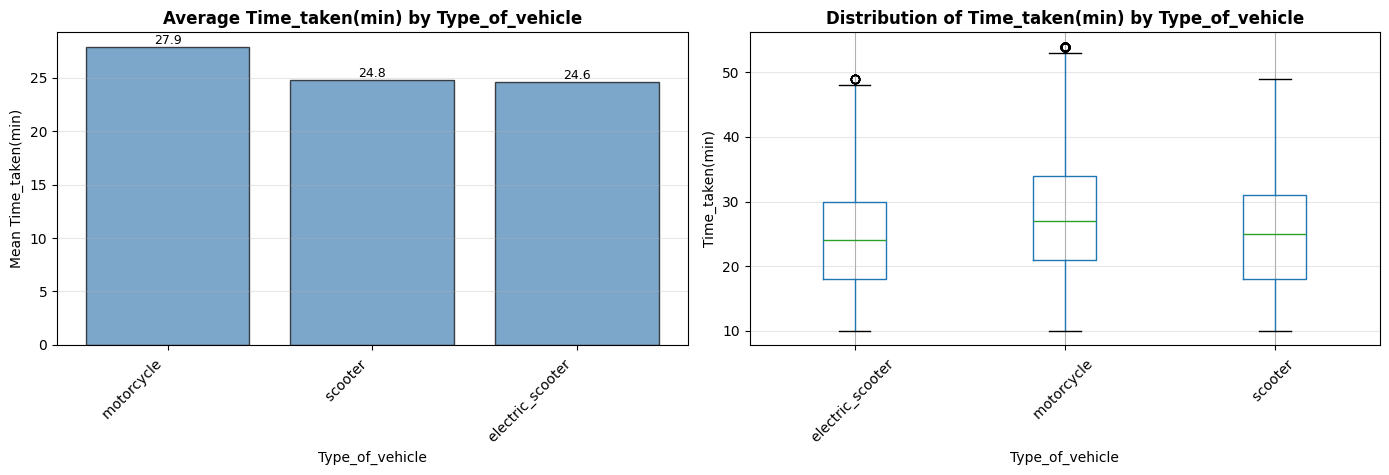


📊 Summary Statistics (sorted by mean Time_taken(min)):
                    mean  median  count   std
Type_of_vehicle                              
motorcycle         27.85    27.0  22433  9.59
scooter            24.78    25.0  12598  8.64
electric_scooter   24.59    24.0   3033  8.58

💡 Key Insight:
   • Best category: 'motorcycle ' (Avg Time_taken(min): 27.85)
   • Worst category: 'electric_scooter ' (Avg Time_taken(min): 24.59)
   • Difference: 3.26

📈 Statistical Significance (ANOVA):
   • F-statistic: 524.8602
   • p-value: 0.0000
   • ✅ Type_of_vehicle has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: Type_of_vehicle_merged → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


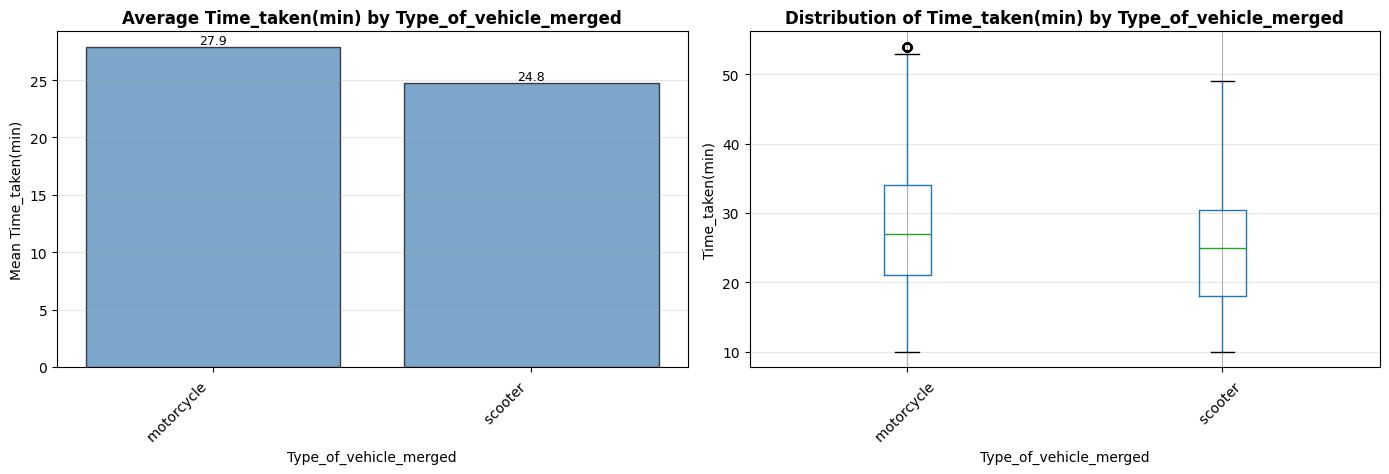


📊 Summary Statistics (sorted by mean Time_taken(min)):
                         mean  median  count   std
Type_of_vehicle_merged                            
motorcycle              27.85    27.0  22433  9.59
scooter                 24.75    25.0  15631  8.63

💡 Key Insight:
   • Best category: 'motorcycle ' (Avg Time_taken(min): 27.85)
   • Worst category: 'scooter ' (Avg Time_taken(min): 24.75)
   • Difference: 3.10

📈 Statistical Significance (ANOVA):
   • F-statistic: 1048.6282
   • p-value: 0.0000
   • ✅ Type_of_vehicle_merged has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: order_day_of_week → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


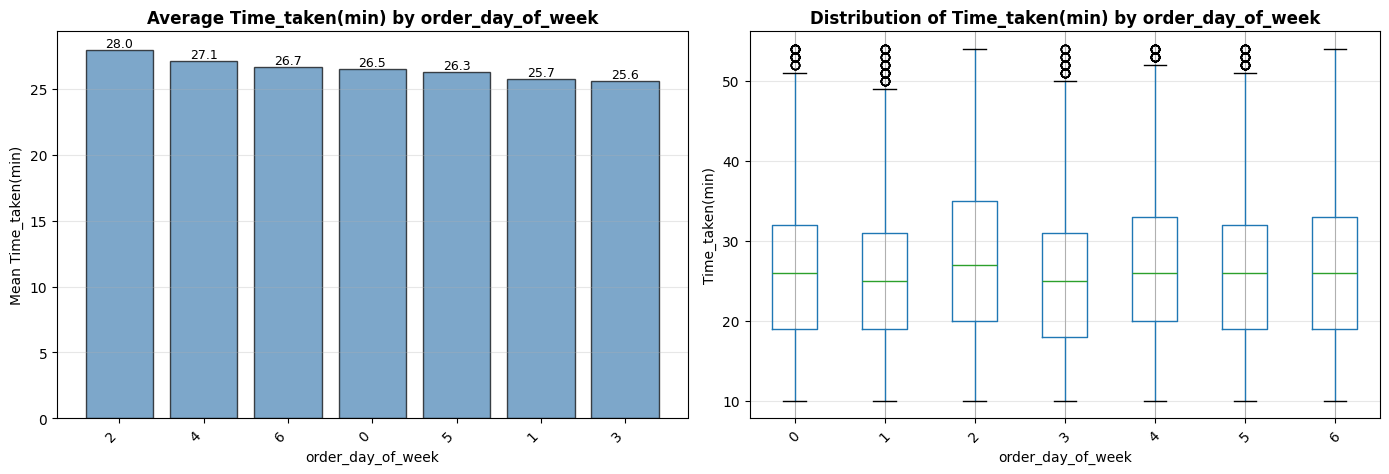


📊 Summary Statistics (sorted by mean Time_taken(min)):
                    mean  median  count   std
order_day_of_week                            
2                  27.96    27.0   5973  9.62
4                  27.13    26.0   5834  9.45
6                  26.68    26.0   5198  9.35
0                  26.47    26.0   5181  9.30
5                  26.29    26.0   5241  9.29
1                  25.71    25.0   5341  9.06
3                  25.57    25.0   5296  8.94

💡 Key Insight:
   • Best category: '2' (Avg Time_taken(min): 27.96)
   • Worst category: '3' (Avg Time_taken(min): 25.57)
   • Difference: 2.39

📈 Statistical Significance (ANOVA):
   • F-statistic: 44.5721
   • p-value: 0.0000
   • ✅ order_day_of_week has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: order_month → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


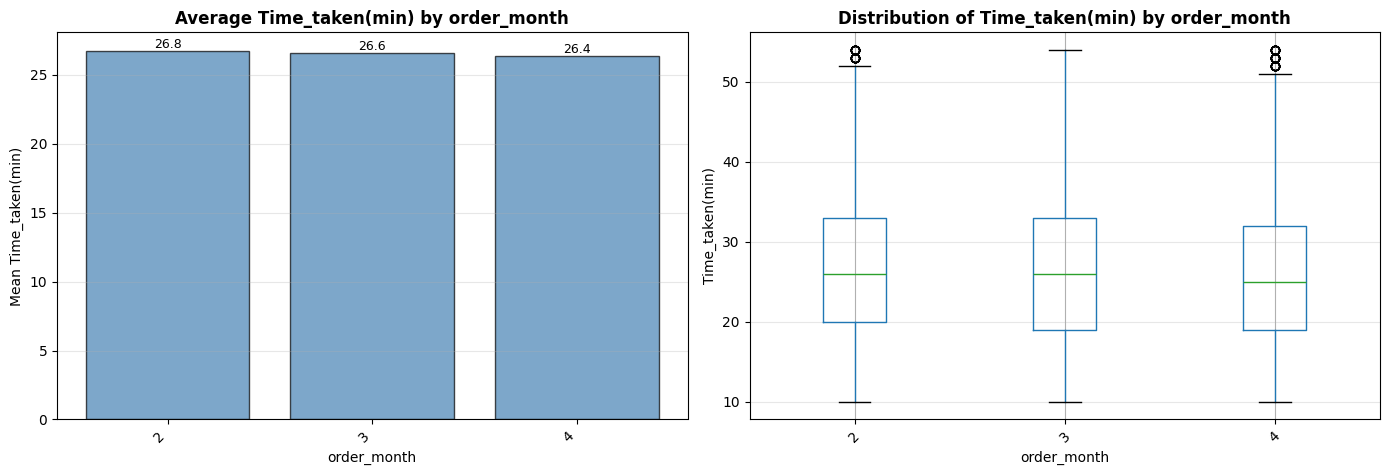


📊 Summary Statistics (sorted by mean Time_taken(min)):
              mean  median  count   std
order_month                            
2            26.75    26.0   5465  9.32
3            26.58    26.0  27193  9.35
4            26.39    25.0   5406  9.25

💡 Key Insight:
   • Best category: '2' (Avg Time_taken(min): 26.75)
   • Worst category: '4' (Avg Time_taken(min): 26.39)
   • Difference: 0.36

📈 Statistical Significance (ANOVA):
   • F-statistic: 2.0403
   • p-value: 0.1300
   • ❌ order_month does NOT have significant impact on Time_taken(min)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: order_hour → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


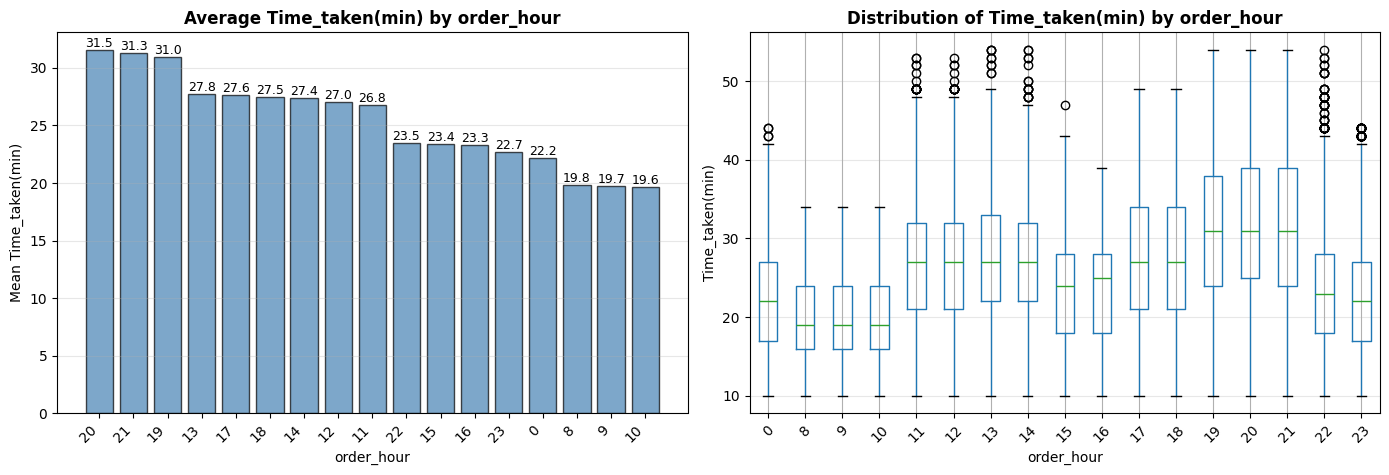


📊 Summary Statistics (sorted by mean Time_taken(min)):
             mean  median  count   std
order_hour                            
20          31.52    31.0   3989  9.81
21          31.32    31.0   4112  9.93
19          30.99    31.0   4071  9.78
13          27.77    27.0    679  8.50
17          27.61    27.0   3727  8.45
18          27.47    27.0   3936  8.65
14          27.36    27.0    683  8.19
12          27.04    27.0    788  8.65
11          26.75    27.0   1703  8.20
22          23.48    23.0   3895  7.93
15          23.38    24.0    757  6.91
16          23.31    25.0    611  6.75
23          22.69    22.0   3845  7.32
0           22.17    22.0    369  7.00
8           19.84    19.0   1563  5.59
9           19.74    19.0   1643  5.53
10          19.62    19.0   1693  5.52

💡 Key Insight:
   • Best category: '20' (Avg Time_taken(min): 31.52)
   • Worst category: '10' (Avg Time_taken(min): 19.62)
   • Difference: 11.90

📈 Statistical Significance (ANOVA):
   • F-statistic: 

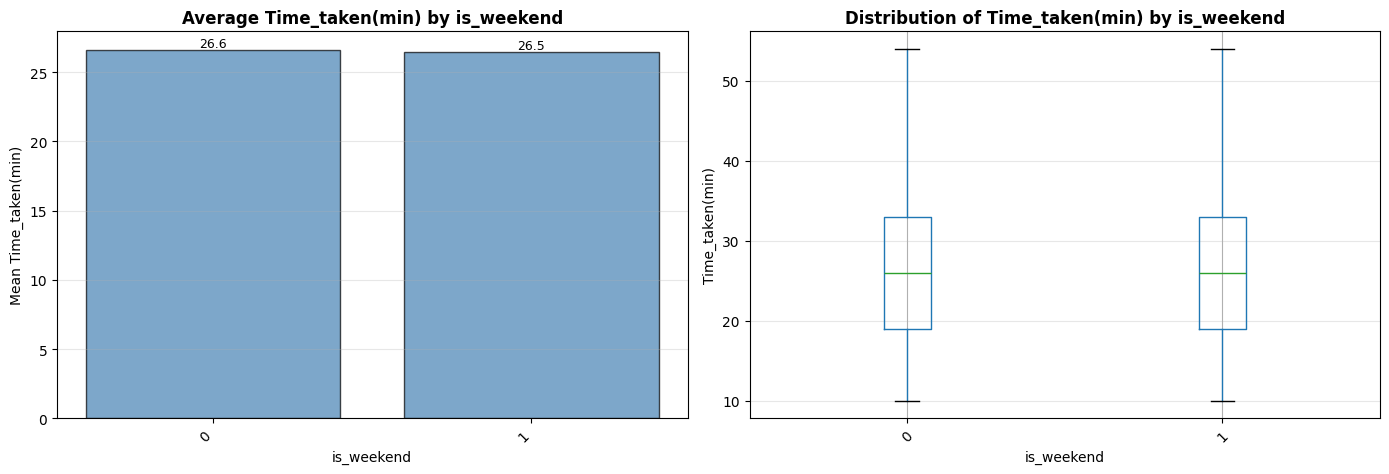


📊 Summary Statistics (sorted by mean Time_taken(min)):
             mean  median  count   std
is_weekend                            
0           26.61    26.0  27625  9.33
1           26.48    26.0  10439  9.32

💡 Key Insight:
   • Best category: '0' (Avg Time_taken(min): 26.61)
   • Worst category: '1' (Avg Time_taken(min): 26.48)
   • Difference: 0.13

📈 Statistical Significance (ANOVA):
   • F-statistic: 1.4206
   • p-value: 0.2333
   • ❌ is_weekend does NOT have significant impact on Time_taken(min)

────────────────────────────────────────────────────────────────────────────────
▶ Analyzing: is_rush_hour → Impact on Time_taken(min)
────────────────────────────────────────────────────────────────────────────────


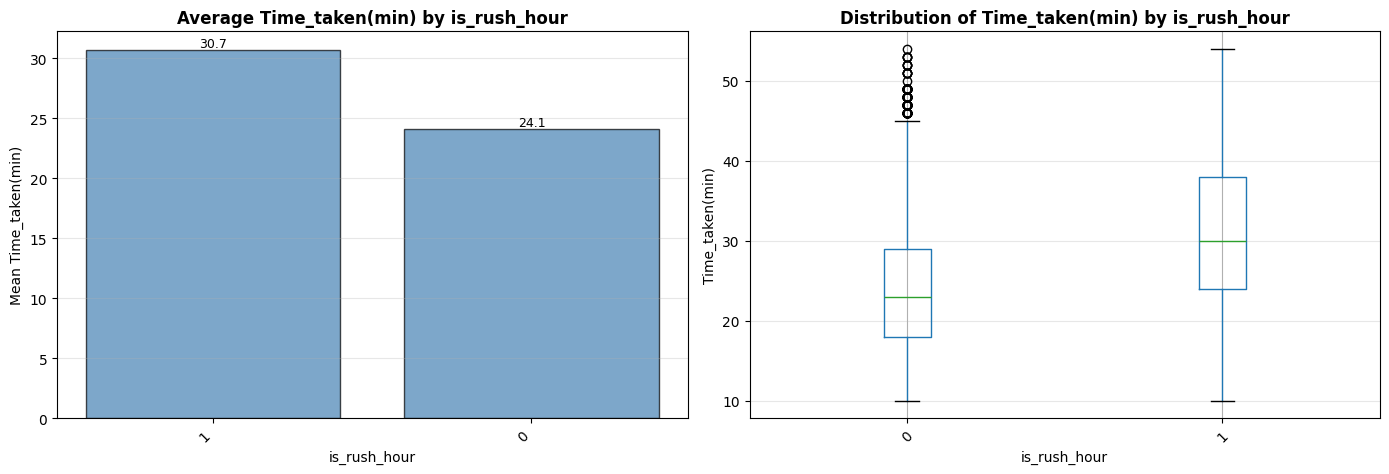


📊 Summary Statistics (sorted by mean Time_taken(min)):
               mean  median  count   std
is_rush_hour                            
1             30.69    30.0  14322  9.74
0             24.10    23.0  23742  8.12

💡 Key Insight:
   • Best category: '1' (Avg Time_taken(min): 30.69)
   • Worst category: '0' (Avg Time_taken(min): 24.10)
   • Difference: 6.59

📈 Statistical Significance (ANOVA):
   • F-statistic: 5050.0044
   • p-value: 0.0000
   • ✅ is_rush_hour has SIGNIFICANT impact on Time_taken(min) (p < 0.05)

🚀 QUICK INSIGHTS: TOP FEATURES AFFECTING TARGET

📈 TOP NUMERICAL FEATURES (by correlation):
   1. multiple_deliveries: 0.3848 ↑
   2. Delivery_person_Ratings: -0.3619 ↓
   3. Delivery_person_Age: 0.2963 ↑
   4. prep_time_minutes: -0.0055 ↓
   5. delivery_distance_km: -0.0018 ↓

📊 TOP CATEGORICAL FEATURES (by statistical significance):
   1. is_rush_hour: F-stat=5050.00, p=0.0000 ✅
   2. Road_traffic_density: F-stat=2895.94, p=0.0000 ✅
   3. Vehicle_condition: F-stat=1635

In [18]:
# Run the analysis
bivariate_analysis(df, num_col, cat_col, target_col)

# # Run quick insights
quick_insights(df, num_col, cat_col, target_col)

### Multivariate Analysis

In [19]:
numeric_df = df.select_dtypes(include='number')

# Calculate correlation and sort by value (highest to lowest)
numeric_df.corr()['Time_taken(min)'].sort_values(ascending=False)

Time_taken(min)            1.000000
multiple_deliveries        0.384773
is_rush_hour               0.342253
Delivery_person_Age        0.296331
order_hour                 0.187908
order_day_of_week          0.006537
delivery_distance_km      -0.001789
prep_time_minutes         -0.005461
is_weekend                -0.006109
order_month               -0.010353
Vehicle_condition         -0.241751
Delivery_person_Ratings   -0.361930
Name: Time_taken(min), dtype: float64

### Analyze Interactions with Multiple Deliveries

#### Check Multicollinearity

In [20]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# Prepare features (excluding target)
feature_cols = ['multiple_deliveries', 'is_rush_hour', 'Delivery_person_Age', 
                'Delivery_person_Ratings', 'Vehicle_condition', 'delivery_distance_km',
                'prep_time_minutes', 'order_hour', 'order_day_of_week']

# Get numeric features only
X = numeric_df[feature_cols].dropna()

# Calculate VIF (Variance Inflation Factor)
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("="*60)
print("MULTICOLLINEARITY CHECK (VIF Score)")
print("="*60)
print("VIF < 5: No multicollinearity ✅")
print("VIF 5-10: Moderate multicollinearity ⚠️")
print("VIF > 10: High multicollinearity ❌\n")
print(vif_data.sort_values('VIF', ascending=False))
print("\n")

# Correlation matrix heatmap for these features
corr_matrix = X.corr()
print("Correlation Matrix (key features):")
print(corr_matrix['multiple_deliveries'].sort_values(ascending=False))

MULTICOLLINEARITY CHECK (VIF Score)
VIF < 5: No multicollinearity ✅
VIF 5-10: Moderate multicollinearity ⚠️
VIF > 10: High multicollinearity ❌

                   feature        VIF
3  Delivery_person_Ratings  37.935122
2      Delivery_person_Age  23.885267
7               order_hour  14.432876
6        prep_time_minutes   6.791426
8        order_day_of_week   3.283300
0      multiple_deliveries   2.816613
4        Vehicle_condition   2.513790
1             is_rush_hour   1.773716
5     delivery_distance_km   1.008574


Correlation Matrix (key features):
multiple_deliveries        1.000000
is_rush_hour               0.131222
Delivery_person_Age        0.115038
order_hour                 0.070928
delivery_distance_km       0.001197
order_day_of_week         -0.006195
prep_time_minutes         -0.007731
Vehicle_condition         -0.104706
Delivery_person_Ratings   -0.124414
Name: multiple_deliveries, dtype: float64


### Interaction Features & Test Their Impact

In [21]:
# Create interaction features
df_analysis = numeric_df.copy()

# 1. Rush hour × multiple_deliveries
df_analysis['rush_x_deliveries'] = df_analysis['is_rush_hour'] * df_analysis['multiple_deliveries']

# 2. Ratings × multiple_deliveries (low ratings might amplify delays)
df_analysis['ratings_x_deliveries'] = df_analysis['Delivery_person_Ratings'] * df_analysis['multiple_deliveries']

# 3. Age × multiple_deliveries (older drivers might be slower with multiple deliveries)
df_analysis['age_x_deliveries'] = df_analysis['Delivery_person_Age'] * df_analysis['multiple_deliveries']

# 4. Distance × deliveries (longer distance might make multiple deliveries worse)
df_analysis['distance_x_deliveries'] = df_analysis['delivery_distance_km'] * df_analysis['multiple_deliveries']

print("="*60)
print("INTERACTION FEATURES - CORRELATION WITH TIME_TAKEN")
print("="*60)

# Calculate correlations
interaction_cols = ['rush_x_deliveries', 'ratings_x_deliveries', 'age_x_deliveries', 'distance_x_deliveries']
for col in interaction_cols:
    corr = df_analysis[col].corr(df_analysis['Time_taken(min)'])
    print(f"{col:25s}: {corr:.4f}")

print("\nComparison with original features:")
print(f"multiple_deliveries alone      : {numeric_df['multiple_deliveries'].corr(numeric_df['Time_taken(min)']):.4f}")
print(f"is_rush_hour alone             : {numeric_df['is_rush_hour'].corr(numeric_df['Time_taken(min)']):.4f}")
print(f"rush_x_deliveries (interaction): {df_analysis['rush_x_deliveries'].corr(df_analysis['Time_taken(min)']):.4f}")
print("\n")

INTERACTION FEATURES - CORRELATION WITH TIME_TAKEN
rush_x_deliveries        : 0.4231
ratings_x_deliveries     : 0.3522
age_x_deliveries         : 0.4249
distance_x_deliveries    : 0.0211

Comparison with original features:
multiple_deliveries alone      : 0.3848
is_rush_hour alone             : 0.3423
rush_x_deliveries (interaction): 0.4231




### Group by Rush Hour - Compare Correlations

In [22]:
print("="*60)
print("CORRELATION COMPARISON: RUSH HOUR vs NON-RUSH HOUR")
print("="*60)

# Split data by rush hour
rush_data = numeric_df[numeric_df['is_rush_hour'] == 1]
non_rush_data = numeric_df[numeric_df['is_rush_hour'] == 0]

# Features to compare
features_to_compare = ['multiple_deliveries', 'Delivery_person_Ratings', 
                       'Delivery_person_Age', 'Vehicle_condition', 
                       'delivery_distance_km', 'prep_time_minutes']

# Create comparison dataframe
comparison = pd.DataFrame()
for feature in features_to_compare:
    rush_corr = rush_data[feature].corr(rush_data['Time_taken(min)']) if len(rush_data) > 0 else np.nan
    non_rush_corr = non_rush_data[feature].corr(non_rush_data['Time_taken(min)']) if len(non_rush_data) > 0 else np.nan
    diff = rush_corr - non_rush_corr if not np.isnan(rush_corr) and not np.isnan(non_rush_corr) else np.nan
    
    comparison.loc[feature, 'Rush Hour'] = rush_corr
    comparison.loc[feature, 'Non-Rush Hour'] = non_rush_corr
    comparison.loc[feature, 'Difference'] = diff

print(comparison.round(4))
print("\n")

# Statistical test (t-test) to see if correlations are significantly different
print("="*60)
print("STATISTICAL SIGNIFICANCE OF DIFFERENCES")
print("="*60)
print("Comparing multiple_deliveries impact during rush vs non-rush:\n")

# Fisher's Z-test for correlation difference
def compare_correlations(r1, n1, r2, n2, feature_name):
    # Fisher's Z transformation
    z1 = np.arctanh(r1)
    z2 = np.arctanh(r2)
    
    # Standard error
    se = np.sqrt(1/(n1-3) + 1/(n2-3))
    
    # Z-statistic
    z_score = (z1 - z2) / se
    
    # P-value (two-tailed)
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
    
    print(f"Feature: {feature_name}")
    print(f"  Rush hour r={r1:.4f} (n={n1})")
    print(f"  Non-rush r={r2:.4f} (n={n2})")
    print(f"  Z-score: {z_score:.4f}, p-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"  ✅ Significant difference at 95% confidence")
    else:
        print(f"  ❌ No significant difference")
    print()

# Run tests
compare_correlations(
    rush_data['multiple_deliveries'].corr(rush_data['Time_taken(min)']), len(rush_data),
    non_rush_data['multiple_deliveries'].corr(non_rush_data['Time_taken(min)']), len(non_rush_data),
    "multiple_deliveries"
)

CORRELATION COMPARISON: RUSH HOUR vs NON-RUSH HOUR


                         Rush Hour  Non-Rush Hour  Difference
multiple_deliveries         0.3954         0.3388      0.0565
Delivery_person_Ratings    -0.3484        -0.3693      0.0208
Delivery_person_Age         0.3288         0.3076      0.0212
Vehicle_condition          -0.2999        -0.2350     -0.0649
delivery_distance_km       -0.0120         0.0036     -0.0155
prep_time_minutes          -0.0080        -0.0062     -0.0018


STATISTICAL SIGNIFICANCE OF DIFFERENCES
Comparing multiple_deliveries impact during rush vs non-rush:

Feature: multiple_deliveries
  Rush hour r=0.3954 (n=14322)
  Non-rush r=0.3388 (n=23742)
  Z-score: 6.1785, p-value: 0.0000
  ✅ Significant difference at 95% confidence



### Advanced Analysis: Conditional Effects

In [23]:
print("="*60)
print("CONDITIONAL EFFECTS: How impact of deliveries changes by context")
print("="*60)

# Effect of deliveries on time, conditioned on rush hour
from sklearn.linear_model import LinearRegression

# Model 1: Simple effect
model_simple = LinearRegression()
model_simple.fit(df_analysis[['multiple_deliveries']], df_analysis['Time_taken(min)'])
print(f"Average effect of +1 delivery: {model_simple.coef_[0]:.2f} minutes")

# Model 2: Interaction effect
model_interaction = LinearRegression()
model_interaction.fit(df_analysis[['multiple_deliveries', 'is_rush_hour', 'rush_x_deliveries']], 
                       df_analysis['Time_taken(min)'])
coef = model_interaction.coef_
print(f"\nEffect in NON-rush hour: +{coef[0]:.2f} minutes per delivery")
print(f"Additional effect during RUSH hour: +{coef[2]:.2f} minutes per delivery")
print(f"Total effect during RUSH hour: +{coef[0] + coef[2]:.2f} minutes per delivery")

# Group by multiple categories
print("\n" + "="*60)
print("STRATIFIED ANALYSIS: By rush hour AND ratings")
print("="*60)

# Create ratings groups
df_analysis['ratings_group'] = pd.cut(df_analysis['Delivery_person_Ratings'], 
                                        bins=[0, 3, 4, 5], 
                                        labels=['Low (<3)', 'Medium (3-4)', 'High (>4)'])

# Cross-tabulation
cross_effect = df_analysis.groupby(['is_rush_hour', 'ratings_group'])['multiple_deliveries']\
    .corr(df_analysis['Time_taken(min)']).unstack()

print(cross_effect.round(4))

CONDITIONAL EFFECTS: How impact of deliveries changes by context
Average effect of +1 delivery: 6.27 minutes

Effect in NON-rush hour: +5.17 minutes per delivery
Additional effect during RUSH hour: +1.03 minutes per delivery
Total effect during RUSH hour: +6.20 minutes per delivery

STRATIFIED ANALYSIS: By rush hour AND ratings
ratings_group  Low (<3)  Medium (3-4)  High (>4)
is_rush_hour                                    
0                0.1607        0.2875     0.3298
1                   NaN        0.2789     0.3985


C:\Users\iampr\AppData\Local\Temp\ipykernel_22652\2766990347.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cross_effect = df_analysis.groupby(['is_rush_hour', 'ratings_group'])['multiple_deliveries']\


In [24]:
df.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'City', 'Time_taken(min)',
       'Type_of_vehicle_merged', 'delivery_distance_km', 'order_hour',
       'order_day_of_week', 'order_month', 'is_weekend', 'prep_time_minutes',
       'is_rush_hour'],
      dtype='object')

In [26]:
df.to_csv("../data/cleaned_eda.csv", index=False)